# 🌾 Seasonal Agriculture Performance Analysis

## VOIS Internship Major Project

### Project Objective

This project analyzes historical agricultural data to identify
seasonal, crop-wise, regional and yearly patterns in agricultural
production and yield.

### Key Areas of Analysis

- Seasonal agricultural performance
- Crop-wise production and yield
- State/region-wise performance
- Production trends over time
- Yield trends
- Crop-season relationships
- Area vs production relationship
- Statistical analysis
- Evidence-based agricultural recommendations

### Development Environment

Google Colab + Python

In [ ]:
# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.xlsx to seasonal_agriculture_performance_dataset.xlsx


In [ ]:
import os

print("Files in Colab:")
print(os.listdir())

Files in Colab:
['.config', 'seasonal_agriculture_performance_dataset.xlsx', 'sample_data']


In [ ]:
df = pd.read_excel("seasonal_agriculture_performance_dataset.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4000, 28)


In [ ]:
print(df.columns.tolist())
display(df.head())


['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
# ============================================
# STEP 2: DATASET INITIAL INSPECTION
# ============================================

print("DATASET SHAPE")
print("=" * 50)
print(df.shape)

print("\nCOLUMN NAMES")
print("=" * 50)
print(df.columns.tolist())

print("\nFIRST 5 ROWS")
print("=" * 50)
display(df.head())

DATASET SHAPE
(4000, 28)

COLUMN NAMES
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

FIRST 5 ROWS


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
# ============================================
# DATASET INFORMATION
# ============================================

print("DATA TYPES AND DATASET INFORMATION")
print("=" * 50)

df.info()

DATA TYPES AND DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_h

In [ ]:
# ============================================
# MISSING VALUES
# ============================================

print("MISSING VALUES")
print("=" * 50)

print(df.isnull().sum())

MISSING VALUES
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_

In [ ]:
# ============================================
# DUPLICATE RECORDS
# ============================================

print("DUPLICATE ROWS")
print("=" * 50)

print(df.duplicated().sum())

DUPLICATE ROWS
0


In [ ]:
# ============================================
# STEP 3.1: CHECK DUPLICATES
# ============================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# ============================================
# STEP 3.2: CREATE CLEAN DATASET
# ============================================

# Keep the original dataset unchanged
clean_df = df.copy()

print("Original dataset shape:", df.shape)
print("Clean dataset shape:", clean_df.shape)

Original dataset shape: (4000, 28)
Clean dataset shape: (4000, 28)


In [ ]:
# ============================================
# STEP 3.3: CLEAN COLUMN NAMES
# ============================================

clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print("Cleaned column names:")
print(clean_df.columns.tolist())

Cleaned column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
# ============================================
# STEP 3.4: CLEAN TEXT COLUMNS
# ============================================

text_columns = clean_df.select_dtypes(include="object").columns

for col in text_columns:
    clean_df[col] = clean_df[col].str.strip()

print("Text columns cleaned successfully.")

Text columns cleaned successfully.


In [ ]:
# ============================================
# STEP 3.5: HANDLE MISSING VALUES
# ============================================

# Fill missing rainfall using median
clean_df["Rainfall_mm"] = clean_df["Rainfall_mm"].fillna(
    clean_df["Rainfall_mm"].median()
)

# Fill missing soil moisture using median
clean_df["Soil_Moisture_pct"] = clean_df["Soil_Moisture_pct"].fillna(
    clean_df["Soil_Moisture_pct"].median()
)

# Calculate missing yield from production and farm area
yield_mask = (
    clean_df["Yield_Tonnes_Ha"].isna()
    & clean_df["Farm_Area_Hectares"].notna()
    & clean_df["Production_Tonnes"].notna()
    & (clean_df["Farm_Area_Hectares"] > 0)
)

clean_df.loc[yield_mask, "Yield_Tonnes_Ha"] = (
    clean_df.loc[yield_mask, "Production_Tonnes"]
    / clean_df.loc[yield_mask, "Farm_Area_Hectares"]
)

print("Missing values handled.")

Missing values handled.


In [ ]:
# ============================================
# STEP 3.6: VERIFY CLEANING
# ============================================

print("Missing values after cleaning:")
print(clean_df.isnull().sum())

Missing values after cleaning:
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct   

In [ ]:
# ============================================
# STEP 3.7: CHECK FOR NEGATIVE VALUES
# ============================================

numeric_columns = clean_df.select_dtypes(include=np.number).columns

negative_values = {}

for col in numeric_columns:
    count = (clean_df[col] < 0).sum()
    if count > 0:
        negative_values[col] = count

print("Negative value check:")
print(negative_values)

if len(negative_values) == 0:
    print("No negative values found in numerical columns.")

Negative value check:
{'Profit_INR': np.int64(1966)}


In [ ]:
# ============================================
# STEP 3.9: VALIDATE NEGATIVE VALUES
# ============================================

print("NEGATIVE VALUES BY COLUMN")
print("=" * 60)

for col in numeric_columns:
    count = (clean_df[col] < 0).sum()
    if count > 0:
        print(f"{col}: {count} negative values")

NEGATIVE VALUES BY COLUMN
Profit_INR: 1966 negative values


In [ ]:
# ============================================
# STEP 3.10: CHECK KEY AGRICULTURAL VARIABLES
# ============================================

columns_to_check = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Water_Used_m3"
]

for col in columns_to_check:
    print(
        f"{col:35} "
        f"Min: {clean_df[col].min():.2f} | "
        f"Max: {clean_df[col].max():.2f}"
    )

Farm_Area_Hectares                  Min: 0.50 | Max: 15.00
Rainfall_mm                         Min: 80.00 | Max: 1395.20
Avg_Temperature_C                   Min: 16.20 | Max: 39.70
Humidity_pct                        Min: 25.00 | Max: 95.00
Soil_pH                             Min: 5.20 | Max: 8.40
Soil_Moisture_pct                   Min: 8.00 | Max: 47.00
Nitrogen_kg_ha                      Min: 40.00 | Max: 220.00
Phosphorus_kg_ha                    Min: 15.00 | Max: 120.00
Potassium_kg_ha                     Min: 30.00 | Max: 200.00
Fertilizer_kg_ha                    Min: 40.00 | Max: 400.00
Pesticide_Litre_ha                  Min: 0.50 | Max: 12.08
Yield_Tonnes_Ha                     Min: 0.30 | Max: 101.44
Production_Tonnes                   Min: 0.15 | Max: 1424.40
Water_Used_m3                       Min: 128.00 | Max: 40902.00


In [ ]:
# ============================================
# STEP 3.11: VERIFY PROFIT CALCULATION
# ============================================

calculated_profit = (
    clean_df["Revenue_INR"] - clean_df["Total_Cost_INR"]
)

difference = (
    clean_df["Profit_INR"] - calculated_profit
).abs()

print("Maximum difference between recorded and calculated profit:")
print(difference.max())

Maximum difference between recorded and calculated profit:
0


In [ ]:
# ============================================
# STEP 4.1: CALCULATED YIELD
# ============================================

clean_df["Calculated_Yield_Tonnes_Ha"] = (
    clean_df["Production_Tonnes"] /
    clean_df["Farm_Area_Hectares"]
)

print("Calculated yield created successfully.")

display(
    clean_df[
        [
            "Farm_Area_Hectares",
            "Production_Tonnes",
            "Yield_Tonnes_Ha",
            "Calculated_Yield_Tonnes_Ha"
        ]
    ].head()
)

Calculated yield created successfully.


,Farm_Area_Hectares,Production_Tonnes,Yield_Tonnes_Ha,Calculated_Yield_Tonnes_Ha
0,0.53,1.30,2.46,2.452830
1,6.53,1.96,0.30,0.300153
2,4.86,2.53,0.52,0.520576
3,4.50,8.28,1.84,1.840000
4,4.21,9.30,2.21,2.209026


In [ ]:
# ============================================
# STEP 4.2: COMPLETE MISSING YIELD VALUES
# ============================================

missing_yield_before = clean_df["Yield_Tonnes_Ha"].isnull().sum()

clean_df["Yield_Tonnes_Ha"] = clean_df["Yield_Tonnes_Ha"].fillna(
    clean_df["Calculated_Yield_Tonnes_Ha"]
)

missing_yield_after = clean_df["Yield_Tonnes_Ha"].isnull().sum()

print("Missing yield values before:", missing_yield_before)
print("Missing yield values after:", missing_yield_after)

Missing yield values before: 0
Missing yield values after: 0


In [ ]:
# ============================================
# STEP 4.3: YIELD EFFICIENCY
# ============================================

clean_df["Yield_Efficiency"] = (
    clean_df["Production_Tonnes"] /
    clean_df["Farm_Area_Hectares"]
)

print("Yield efficiency created successfully.")

Yield efficiency created successfully.


In [ ]:
# ============================================
# STEP 4.4: PROFIT MARGIN
# ============================================

clean_df["Profit_Margin_pct"] = np.where(
    clean_df["Revenue_INR"] != 0,
    (clean_df["Profit_INR"] / clean_df["Revenue_INR"]) * 100,
    np.nan
)

print("Profit margin created successfully.")

Profit margin created successfully.


In [ ]:
# ============================================
# STEP 4.5: PROFIT / LOSS STATUS
# ============================================

clean_df["Profit_Status"] = np.where(
    clean_df["Profit_INR"] >= 0,
    "Profit",
    "Loss"
)

print("Profit/Loss distribution:")
print(clean_df["Profit_Status"].value_counts())

Profit/Loss distribution:
Profit_Status
Profit    2034
Loss      1966
Name: count, dtype: int64


In [ ]:
# ============================================
# STEP 4.6: FEATURE ENGINEERING SUMMARY
# ============================================

print("New features created:")
print("- Yield_Efficiency")
print("- Profit_Margin_pct")
print("- Profit_Status")

print("\nUpdated dataset shape:")
print(clean_df.shape)

display(
    clean_df[
        [
            "Crop",
            "Season",
            "Farm_Area_Hectares",
            "Production_Tonnes",
            "Yield_Tonnes_Ha",
            "Profit_INR",
            "Profit_Margin_pct",
            "Profit_Status"
        ]
    ].head(10)
)

New features created:
- Yield_Efficiency
- Profit_Margin_pct
- Profit_Status

Updated dataset shape:
(4000, 32)


,Crop,Season,Farm_Area_Hectares,Production_Tonnes,Yield_Tonnes_Ha,Profit_INR,Profit_Margin_pct,Profit_Status
0,Wheat,Kharif,0.53,1.30,2.46,-11852,-38.468030,Loss
1,Maize,Kharif,6.53,1.96,0.30,-451950,-1118.660429,Loss
2,Pulses,Rabi,4.86,2.53,0.52,-124744,-65.494104,Loss
3,Rice,Kharif,4.50,8.28,1.84,-95704,-47.675600,Loss
4,Maize,Zaid,4.21,9.30,2.21,-144352,-74.559288,Loss
5,Pulses,Zaid,5.46,3.93,0.72,-32763,-12.153800,Loss
6,Wheat,Rabi,8.13,20.57,2.53,-41239,-8.735189,Loss
7,Pulses,Kharif,5.34,6.30,1.18,5065,1.147836,Profit
8,Cotton,Zaid,6.98,10.68,1.53,230705,30.523237,Profit
9,Chilli,Rabi,13.69,31.35,2.29,1954835,66.066118,Profit


In [ ]:
# ============================================
# STEP 5.1: DATASET OVERVIEW
# ============================================

print("SEASONAL AGRICULTURE PERFORMANCE ANALYSIS")
print("=" * 60)

print("\nDataset Shape:")
print(clean_df.shape)

print("\nNumber of Farms/Records:")
print(len(clean_df))

print("\nNumber of Crops:")
print(clean_df["Crop"].nunique())

print("\nNumber of States:")
print(clean_df["State"].nunique())

print("\nNumber of Districts:")
print(clean_df["District"].nunique())

print("\nSeasons Available:")
print(clean_df["Season"].unique())

print("\nCrops Available:")
print(clean_df["Crop"].unique())

print("\nStates Available:")
print(clean_df["State"].unique())

SEASONAL AGRICULTURE PERFORMANCE ANALYSIS

Dataset Shape:
(4000, 32)

Number of Farms/Records:
4000

Number of Crops:
8

Number of States:
8

Number of Districts:
10

Seasons Available:
['Kharif' 'Rabi' 'Zaid']

Crops Available:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

States Available:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']


In [ ]:
# ============================================
# STEP 5.2: DESCRIPTIVE STATISTICS
# ============================================

print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(clean_df.describe().T)

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,5.000000e-01,4.260000,7.895000,11.650000,1.500000e+01
Rainfall_mm,4000.0,600.922825,287.193381,8.000000e+01,371.575000,582.000000,831.975000,1.395200e+03
Avg_Temperature_C,4000.0,26.818900,3.818180,1.620000e+01,23.900000,26.900000,29.600000,3.970000e+01
Humidity_pct,4000.0,63.210500,11.960834,2.500000e+01,54.775000,63.000000,71.900000,9.500000e+01
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500000e+00,6.600000,7.300000,8.100000,1.100000e+01
Soil_pH,4000.0,6.701010,0.641461,5.200000e+00,6.260000,6.690000,7.140000,8.400000e+00
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000000e+00,21.800000,26.400000,31.200000,4.700000e+01
Nitrogen_kg_ha,4000.0,120.250825,31.216452,4.000000e+01,98.500000,120.100000,141.225000,2.200000e+02
Phosphorus_kg_ha,4000.0,57.781850,17.015074,1.500000e+01,46.200000,57.500000,69.400000,1.200000e+02
Potassium_kg_ha,4000.0,104.760050,27.742681,3.000000e+01,86.200000,105.100000,123.600000,2.000000e+02


In [ ]:
# ============================================
# STEP 5.3: PROFIT / LOSS DISTRIBUTION
# ============================================

print("PROFIT / LOSS DISTRIBUTION")
print("=" * 60)

profit_counts = clean_df["Profit_Status"].value_counts()

print(profit_counts)

print("\nPercentage Distribution:")
print(
    (clean_df["Profit_Status"].value_counts(normalize=True) * 100)
    .round(2)
)

PROFIT / LOSS DISTRIBUTION
Profit_Status
Profit    2034
Loss      1966
Name: count, dtype: int64

Percentage Distribution:
Profit_Status
Profit    50.85
Loss      49.15
Name: proportion, dtype: float64


In [ ]:
# ============================================
# STEP 6.1: PRODUCTION BY SEASON
# ============================================

season_production = (
    clean_df.groupby("Season")["Production_Tonnes"]
    .sum()
    .sort_values(ascending=False)
)

print("TOTAL PRODUCTION BY SEASON")
print("=" * 60)

display(season_production)

TOTAL PRODUCTION BY SEASON


,Production_Tonnes
Season,
Kharif,82387.61
Rabi,67498.88
Zaid,23098.35


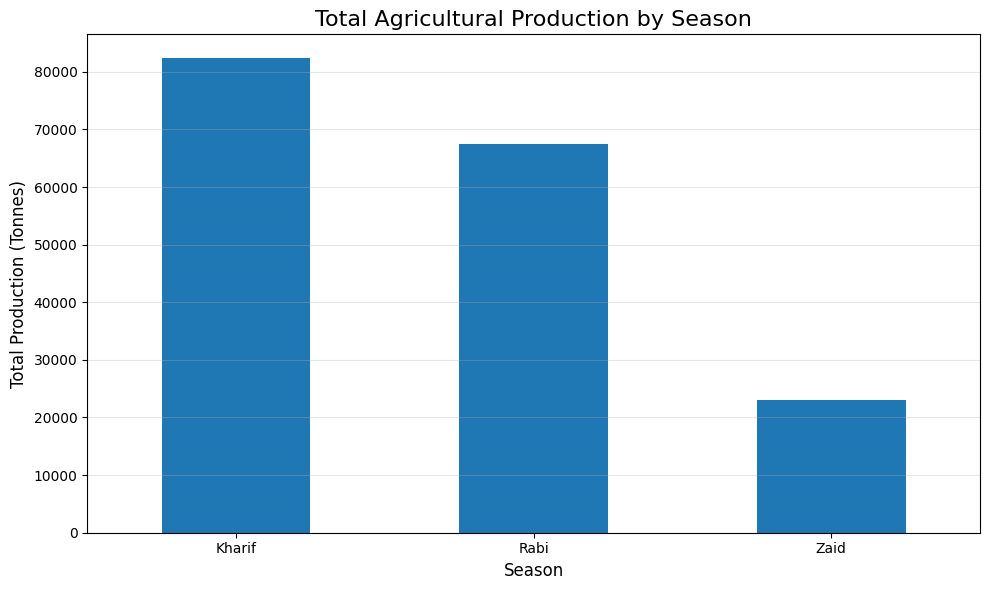

In [ ]:
# ============================================
# STEP 6.2: PRODUCTION BY SEASON - BAR CHART
# ============================================

plt.figure(figsize=(10, 6))

season_production.plot(kind="bar")

plt.title("Total Agricultural Production by Season", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Total Production (Tonnes)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 6.3: BEST-PERFORMING SEASON
# ============================================

best_season = season_production.idxmax()
highest_production = season_production.max()

print("BEST-PERFORMING SEASON")
print("=" * 60)

print(f"Season: {best_season}")
print(f"Total Production: {highest_production:,.2f} tonnes")

BEST-PERFORMING SEASON
Season: Kharif
Total Production: 82,387.61 tonnes


In [ ]:
# ============================================
# STEP 6.4: PRODUCTION SHARE BY SEASON
# ============================================

season_share = (
    season_production /
    season_production.sum()
) * 100

season_share = season_share.round(2)

print("PRODUCTION SHARE BY SEASON")
print("=" * 60)

display(season_share)

PRODUCTION SHARE BY SEASON


,Production_Tonnes
Season,
Kharif,47.63
Rabi,39.02
Zaid,13.35


## Seasonal Performance Analysis

Season-wise production was analyzed to identify the agricultural season contributing the highest total production.

The analysis compares the total production recorded for each season and calculates its contribution to overall agricultural production.

The results provide a data-driven view of seasonal agricultural performance and can support crop planning and resource allocation decisions.

In [ ]:
# ============================================
# STEP 7.1: PRODUCTION BY CROP
# ============================================

crop_production = (
    clean_df.groupby("Crop")["Production_Tonnes"]
    .sum()
    .sort_values(ascending=False)
)

print("TOTAL PRODUCTION BY CROP")
print("=" * 60)

display(crop_production)

TOTAL PRODUCTION BY CROP


,Production_Tonnes
Crop,
Sugarcane,119685.97
Rice,13309.15
Maize,12001.40
Wheat,10348.30
Chilli,5101.75
Cotton,4773.10
Groundnut,4094.07
Pulses,3671.10


In [ ]:
# ============================================
# STEP 7.2: TOP 5 CROPS BY PRODUCTION
# ============================================

top_5_crops = crop_production.head(5)

print("TOP 5 CROPS BY TOTAL PRODUCTION")
print("=" * 60)

display(top_5_crops)

TOP 5 CROPS BY TOTAL PRODUCTION


,Production_Tonnes
Crop,
Sugarcane,119685.97
Rice,13309.15
Maize,12001.40
Wheat,10348.30
Chilli,5101.75


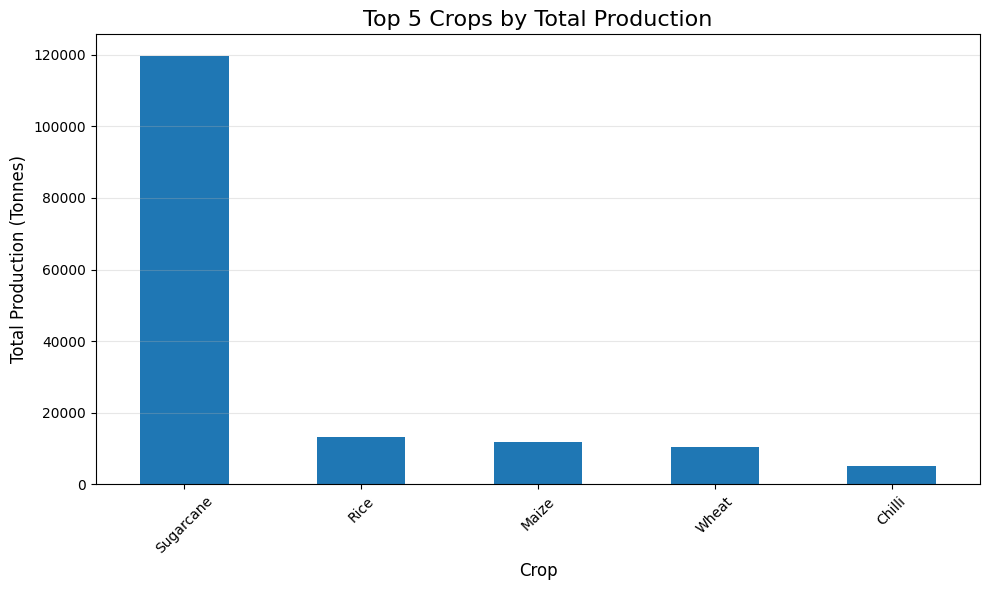

In [ ]:
# ============================================
# STEP 7.3: TOP 5 CROPS - BAR CHART
# ============================================

plt.figure(figsize=(10, 6))

top_5_crops.plot(kind="bar")

plt.title("Top 5 Crops by Total Production", fontsize=16)
plt.xlabel("Crop", fontsize=12)
plt.ylabel("Total Production (Tonnes)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 7.4: HIGHEST-PRODUCING CROP
# ============================================

highest_crop = crop_production.idxmax()
highest_crop_production = crop_production.max()

print("HIGHEST-PRODUCING CROP")
print("=" * 60)

print(f"Crop: {highest_crop}")
print(f"Total Production: {highest_crop_production:,.2f} tonnes")

HIGHEST-PRODUCING CROP
Crop: Sugarcane
Total Production: 119,685.97 tonnes


In [ ]:
# ============================================
# STEP 8.1: AVERAGE YIELD BY CROP
# ============================================

crop_yield = (
    clean_df.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print("AVERAGE YIELD BY CROP")
print("=" * 60)

display(crop_yield)

AVERAGE YIELD BY CROP


,Yield_Tonnes_Ha
Crop,
Sugarcane,46.925049
Maize,2.713176
Rice,2.436758
Wheat,2.107621
Chilli,1.536409
Groundnut,1.318279
Cotton,1.224471
Pulses,0.917032


In [ ]:
# ============================================
# STEP 8.2: TOP 5 CROPS BY AVERAGE YIELD
# ============================================

top_5_yield = crop_yield.head(5)

print("TOP 5 CROPS BY AVERAGE YIELD")
print("=" * 60)

display(top_5_yield)

TOP 5 CROPS BY AVERAGE YIELD


,Yield_Tonnes_Ha
Crop,
Sugarcane,46.925049
Maize,2.713176
Rice,2.436758
Wheat,2.107621
Chilli,1.536409


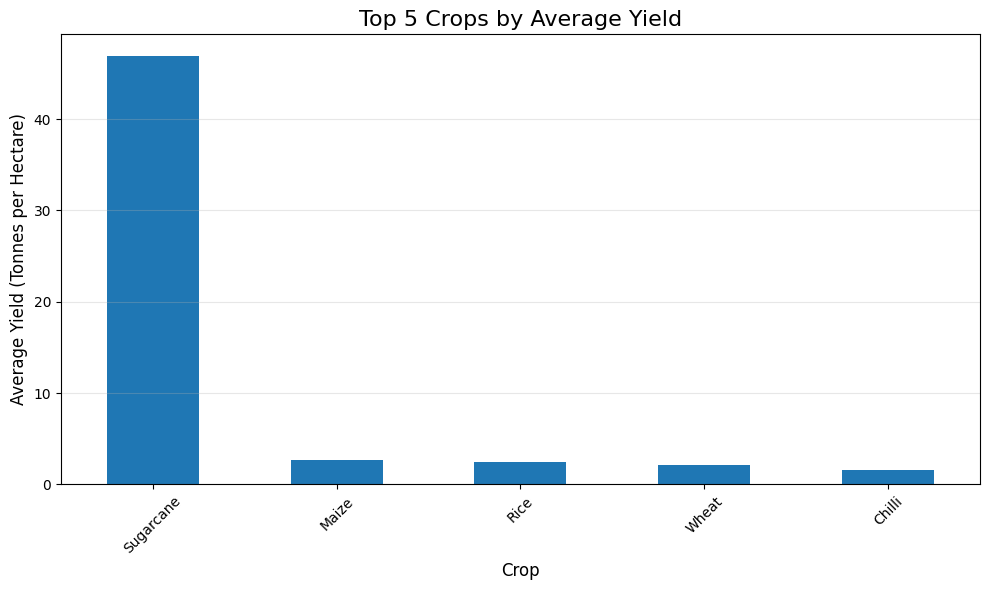

In [ ]:
# ============================================
# STEP 8.3: CROP-WISE YIELD CHART
# ============================================

plt.figure(figsize=(10, 6))

top_5_yield.plot(kind="bar")

plt.title("Top 5 Crops by Average Yield", fontsize=16)
plt.xlabel("Crop", fontsize=12)
plt.ylabel("Average Yield (Tonnes per Hectare)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 8.4: HIGHEST-YIELD CROP
# ============================================

highest_yield_crop = crop_yield.idxmax()
highest_yield = crop_yield.max()

print("HIGHEST-YIELD CROP")
print("=" * 60)

print(f"Crop: {highest_yield_crop}")
print(f"Average Yield: {highest_yield:.2f} tonnes/hectare")

HIGHEST-YIELD CROP
Crop: Sugarcane
Average Yield: 46.93 tonnes/hectare


In [ ]:
# ============================================================
# STEP 9.1: TOTAL PRODUCTION BY STATE
# ============================================================

state_production = (
    clean_df.groupby("State")["Production_Tonnes"]
    .sum()
    .sort_values(ascending=False)
)

print("TOTAL AGRICULTURAL PRODUCTION BY STATE")
print("=" * 60)

display(state_production)

TOTAL AGRICULTURAL PRODUCTION BY STATE


,Production_Tonnes
State,
Punjab,25280.82
Gujarat,23586.01
Karnataka,23341.30
Maharashtra,22519.83
Telangana,20255.16
Tamil Nadu,19807.58
Andhra Pradesh,19527.06
Madhya Pradesh,18667.08


In [ ]:
# ============================================================
# STEP 8.5: BEST-PERFORMING CROP BY YIELD
# ============================================================

crop_yield = (
    clean_df.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

best_yield_crop = crop_yield.idxmax()
highest_yield = crop_yield.max()

print("BEST-PERFORMING CROP BY YIELD")
print("=" * 60)

print(f"Crop: {best_yield_crop}")
print(f"Average Yield: {highest_yield:.2f} tonnes/hectare")

BEST-PERFORMING CROP BY YIELD
Crop: Sugarcane
Average Yield: 46.93 tonnes/hectare


In [ ]:
# ============================================================
# STEP 8.6: TOTAL PRODUCTION BY CROP
# ============================================================

crop_production = (
    clean_df.groupby("Crop")["Production_Tonnes"]
    .sum()
    .sort_values(ascending=False)
)

print("TOTAL PRODUCTION BY CROP")
print("=" * 60)

display(crop_production)

TOTAL PRODUCTION BY CROP


,Production_Tonnes
Crop,
Sugarcane,119685.97
Rice,13309.15
Maize,12001.40
Wheat,10348.30
Chilli,5101.75
Cotton,4773.10
Groundnut,4094.07
Pulses,3671.10


### Step 8.6 – Total Production by Crop

Total agricultural production was aggregated for each crop to compare their overall contribution to agricultural output.

In [ ]:
# ============================================================
# STEP 9.1: TOP 10 STATES BY PRODUCTION
# ============================================================

state_production = (
    clean_df.groupby("State")["Production_Tonnes"]
    .sum()
    .sort_values(ascending=False)
)

top_10_states = state_production.head(10)

print("TOP 10 STATES BY TOTAL AGRICULTURAL PRODUCTION")
print("=" * 60)

display(top_10_states)

TOP 10 STATES BY TOTAL AGRICULTURAL PRODUCTION


,Production_Tonnes
State,
Punjab,25280.82
Gujarat,23586.01
Karnataka,23341.30
Maharashtra,22519.83
Telangana,20255.16
Tamil Nadu,19807.58
Andhra Pradesh,19527.06
Madhya Pradesh,18667.08


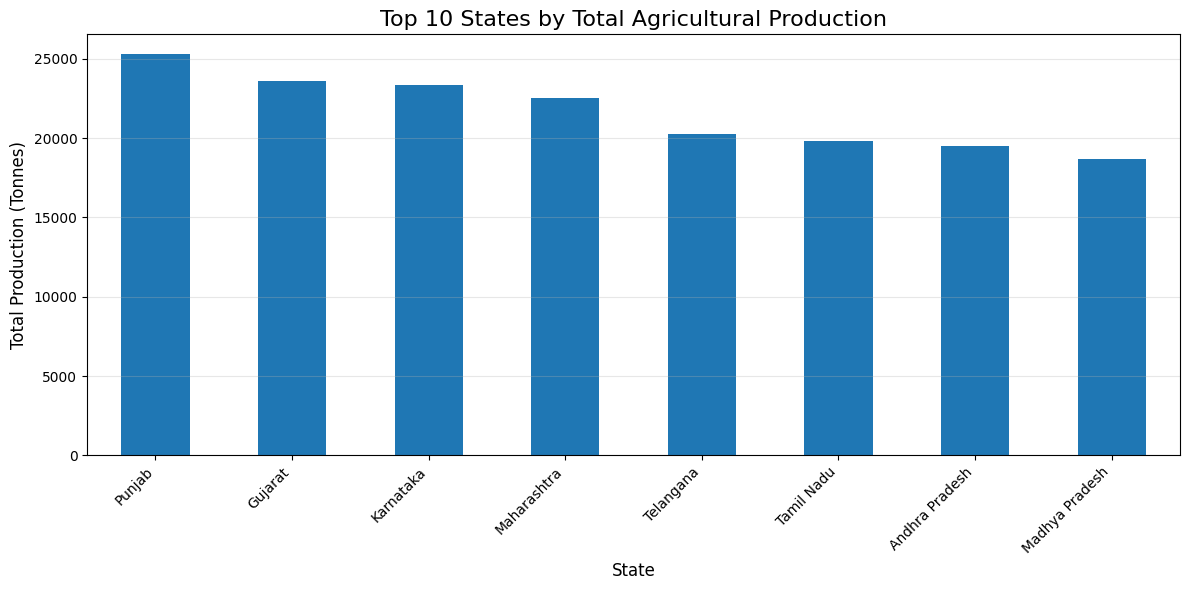

In [ ]:
# ============================================================
# STEP 9.2: STATE-WISE PRODUCTION CHART
# ============================================================

plt.figure(figsize=(12, 6))

top_10_states.plot(kind="bar")

plt.title("Top 10 States by Total Agricultural Production", fontsize=16)
plt.xlabel("State", fontsize=12)
plt.ylabel("Total Production (Tonnes)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 9.3: HIGHEST-PRODUCING STATE
# ============================================================

highest_state = state_production.idxmax()
highest_state_production = state_production.max()

print("HIGHEST-PRODUCING STATE")
print("=" * 60)

print(f"State: {highest_state}")
print(f"Total Production: {highest_state_production:,.2f} tonnes")

HIGHEST-PRODUCING STATE
State: Punjab
Total Production: 25,280.82 tonnes


In [ ]:
# ============================================================
# STEP 9.4: STATE-WISE AVERAGE YIELD
# ============================================================

state_yield = (
    clean_df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

top_10_yield_states = state_yield.head(10)

print("TOP 10 STATES BY AVERAGE YIELD")
print("=" * 60)

display(top_10_yield_states)

TOP 10 STATES BY AVERAGE YIELD


,Yield_Tonnes_Ha
State,
Punjab,6.121116
Gujarat,5.760886
Karnataka,5.751766
Telangana,5.054321
Maharashtra,5.013453
Madhya Pradesh,4.984851
Tamil Nadu,4.871460
Andhra Pradesh,4.630964


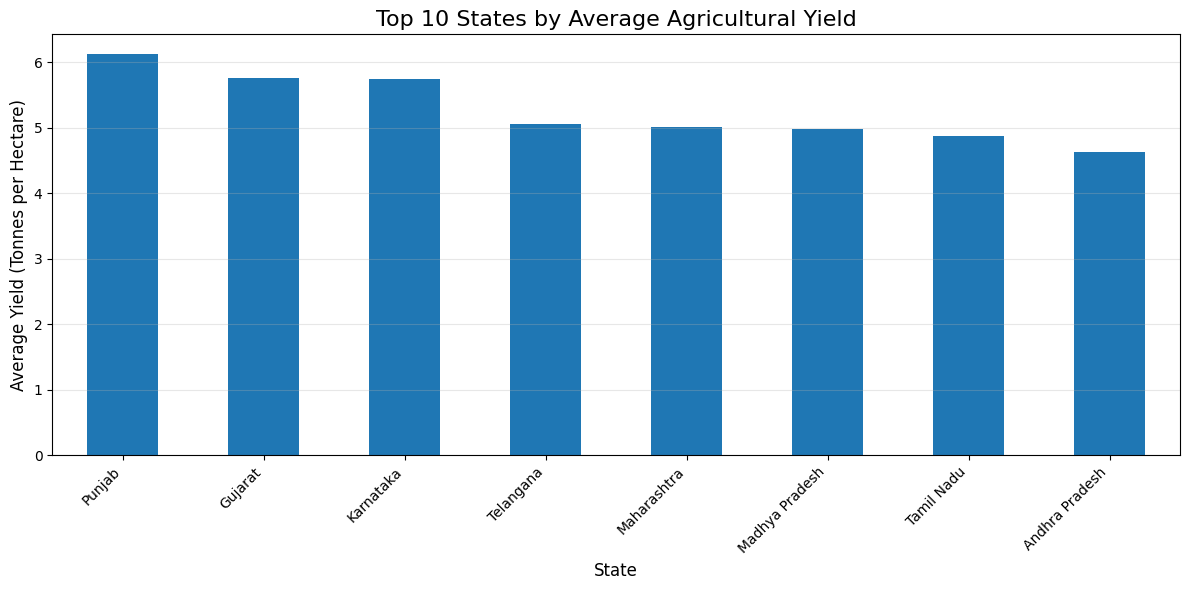

In [ ]:
# ============================================================
# STEP 9.5: STATE-WISE YIELD CHART
# ============================================================

plt.figure(figsize=(12, 6))

top_10_yield_states.plot(kind="bar")

plt.title("Top 10 States by Average Agricultural Yield", fontsize=16)
plt.xlabel("State", fontsize=12)
plt.ylabel("Average Yield (Tonnes per Hectare)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
state_yield = (
    clean_df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

top_10_yield_states = state_yield.head(10)

print("TOP 10 STATES BY AVERAGE YIELD")
print("=" * 50)
display(top_10_yield_states)

TOP 10 STATES BY AVERAGE YIELD


,Yield_Tonnes_Ha
State,
Punjab,6.121116
Gujarat,5.760886
Karnataka,5.751766
Telangana,5.054321
Maharashtra,5.013453
Madhya Pradesh,4.984851
Tamil Nadu,4.871460
Andhra Pradesh,4.630964


In [ ]:
state_yield = (
    clean_df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

top_10_yield_states = state_yield.head(10)

print("TOP 10 STATES BY AVERAGE YIELD")
print("=" * 50)
display(top_10_yield_states)


TOP 10 STATES BY AVERAGE YIELD


,Yield_Tonnes_Ha
State,
Punjab,6.121116
Gujarat,5.760886
Karnataka,5.751766
Telangana,5.054321
Maharashtra,5.013453
Madhya Pradesh,4.984851
Tamil Nadu,4.871460
Andhra Pradesh,4.630964


In [ ]:
highest_yield_state = state_yield.idxmax()
highest_state_yield = state_yield.max()

print("HIGHEST-YIELDING STATE")
print("=" * 50)
print(f"State: {highest_yield_state}")
print(f"Average Yield: {highest_state_yield:.2f} tonnes/hectare")

HIGHEST-YIELDING STATE
State: Punjab
Average Yield: 6.12 tonnes/hectare


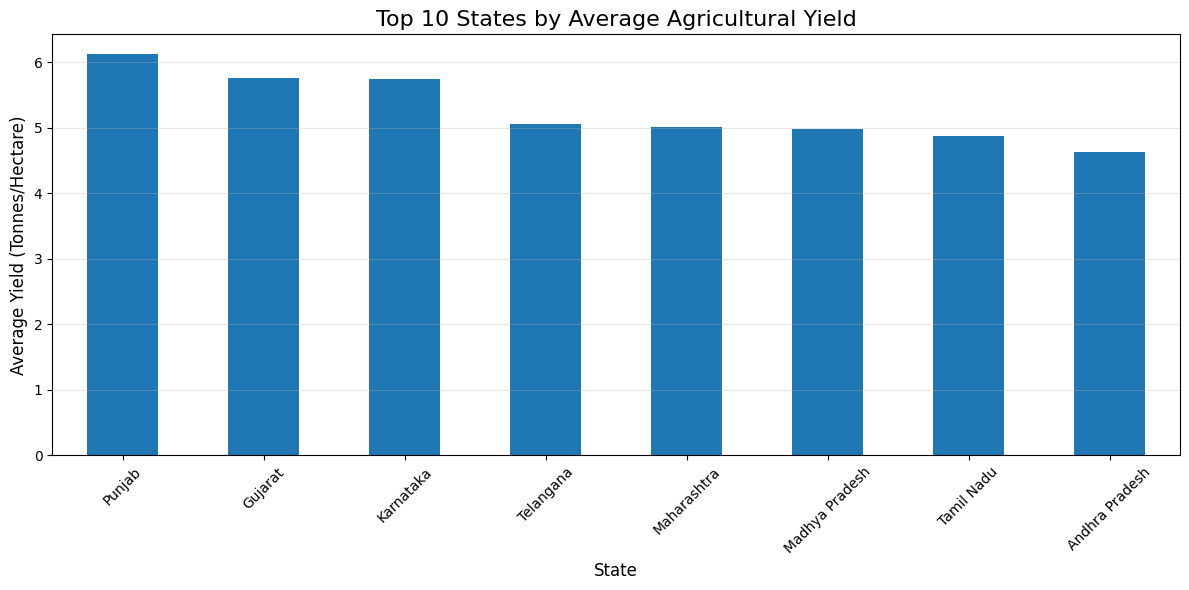

In [ ]:
plt.figure(figsize=(12, 6))

top_10_yield_states.plot(kind="bar")

plt.title("Top 10 States by Average Agricultural Yield", fontsize=16)
plt.xlabel("State", fontsize=12)
plt.ylabel("Average Yield (Tonnes/Hectare)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
crop_season_production = pd.pivot_table(
    clean_df,
    values="Production_Tonnes",
    index="Crop",
    columns="Season",
    aggfunc="sum"
)

print("CROP × SEASON PRODUCTION")
print("=" * 50)

display(crop_season_production)

CROP × SEASON PRODUCTION


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,2675.74,1787.45,638.56
Cotton,2237.84,1897.64,637.62
Groundnut,2024.62,1603.90,465.55
Maize,5463.54,5030.78,1507.08
Pulses,1831.36,1533.28,306.46
Rice,7049.19,4719.24,1540.72
Sugarcane,55759.37,47118.96,16807.64
Wheat,5345.95,3807.63,1194.72


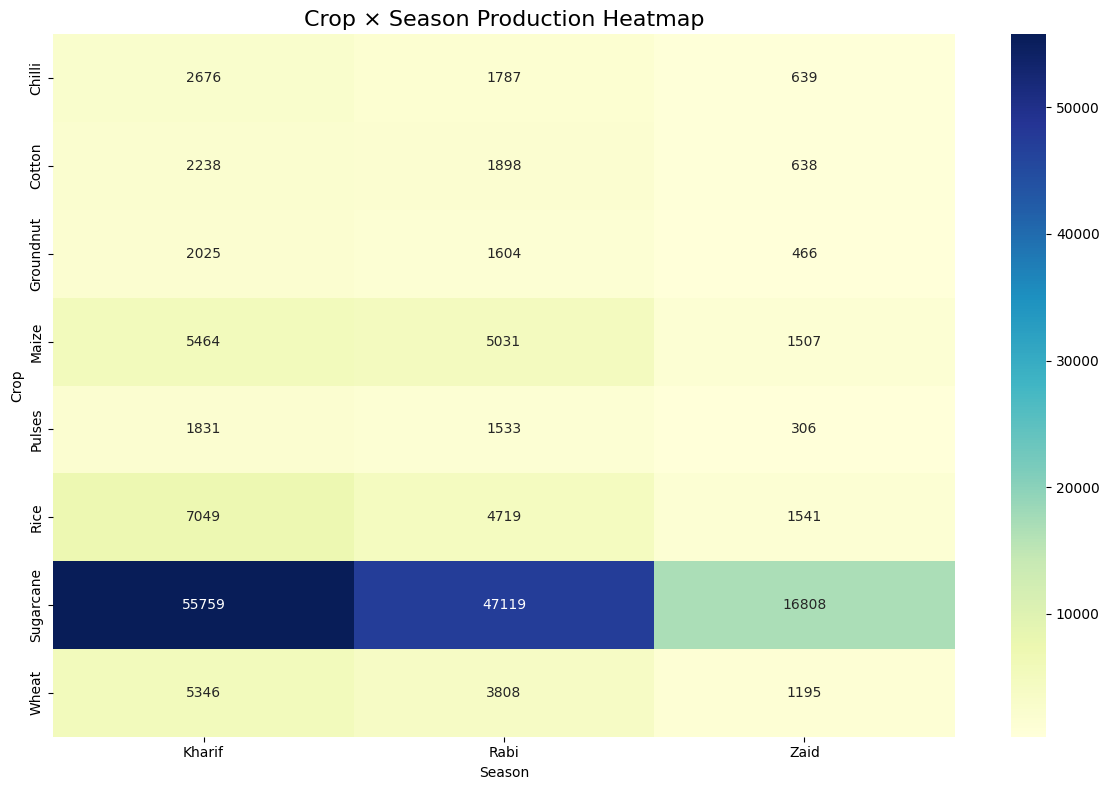

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    crop_season_production,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Crop × Season Production Heatmap", fontsize=16)
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

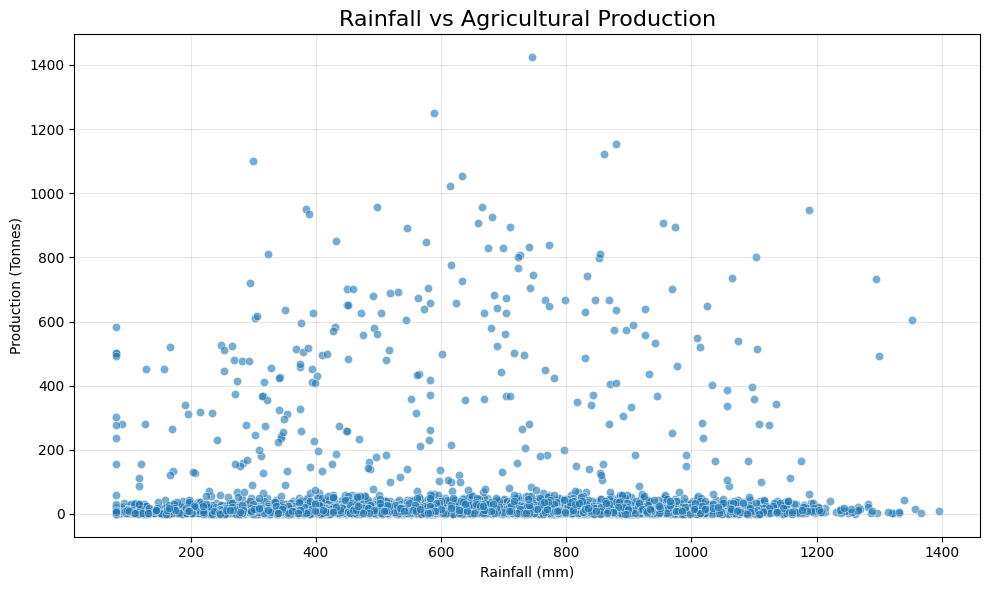

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="Rainfall_mm",
    y="Production_Tonnes",
    alpha=0.6
)

plt.title("Rainfall vs Agricultural Production", fontsize=16)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Production (Tonnes)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
rainfall_production_corr = clean_df[
    ["Rainfall_mm", "Production_Tonnes"]
].corr().iloc[0, 1]

print(
    f"Correlation between Rainfall and Production: "
    f"{rainfall_production_corr:.3f}"
)

Correlation between Rainfall and Production: 0.024


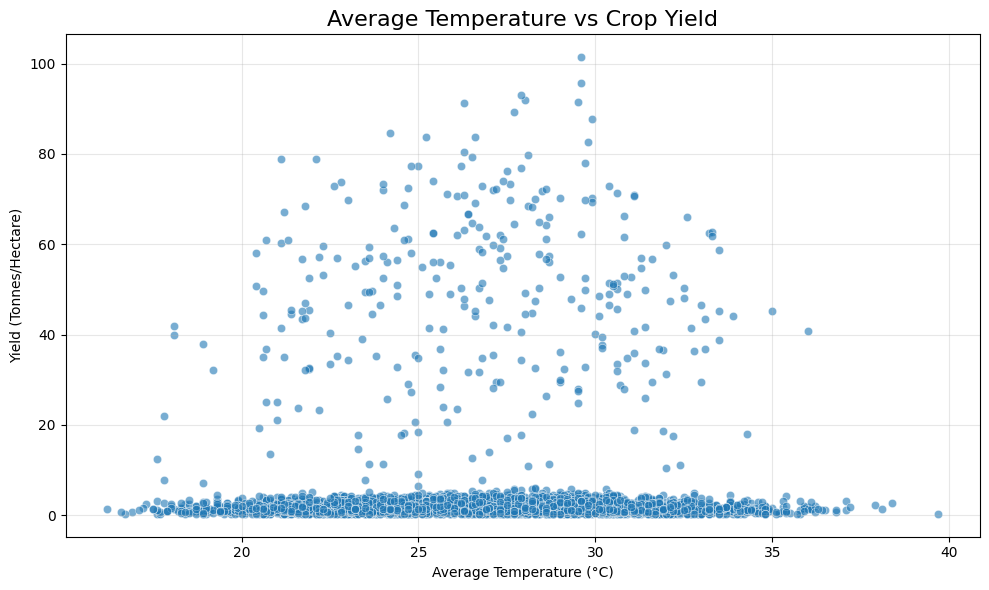

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    alpha=0.6
)

plt.title("Average Temperature vs Crop Yield", fontsize=16)
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Hectare)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
temperature_yield_corr = clean_df[
    ["Avg_Temperature_C", "Yield_Tonnes_Ha"]
].corr().iloc[0, 1]

print(
    f"Correlation between Temperature and Yield: "
    f"{temperature_yield_corr:.3f}"
)

Correlation between Temperature and Yield: 0.009


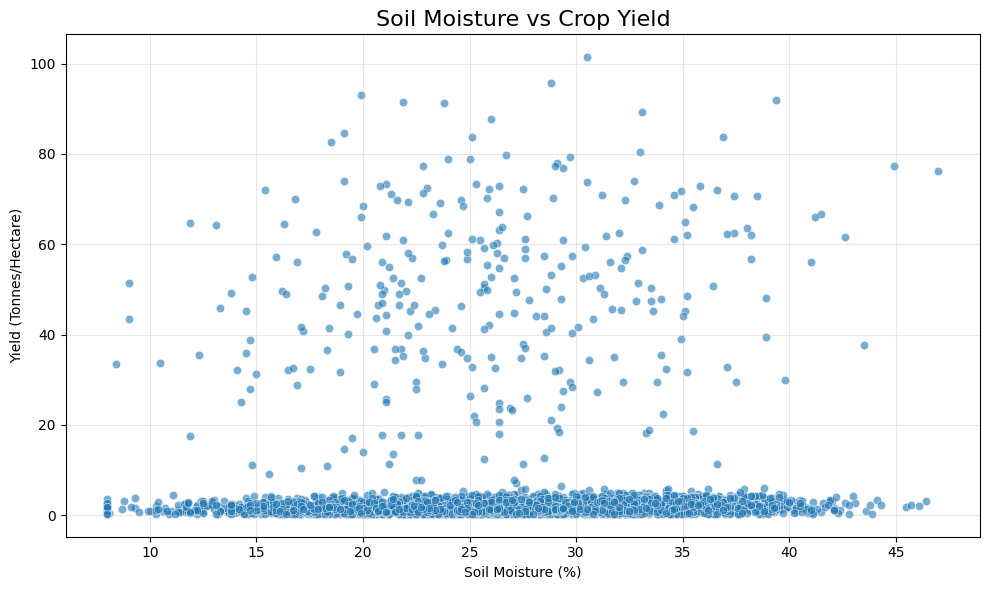

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    alpha=0.6
)

plt.title("Soil Moisture vs Crop Yield", fontsize=16)
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Hectare)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
soil_moisture_yield_corr = clean_df[
    ["Soil_Moisture_pct", "Yield_Tonnes_Ha"]
].corr().iloc[0, 1]

print(
    f"Correlation between Soil Moisture and Yield: "
    f"{soil_moisture_yield_corr:.3f}"
)

Correlation between Soil Moisture and Yield: 0.010


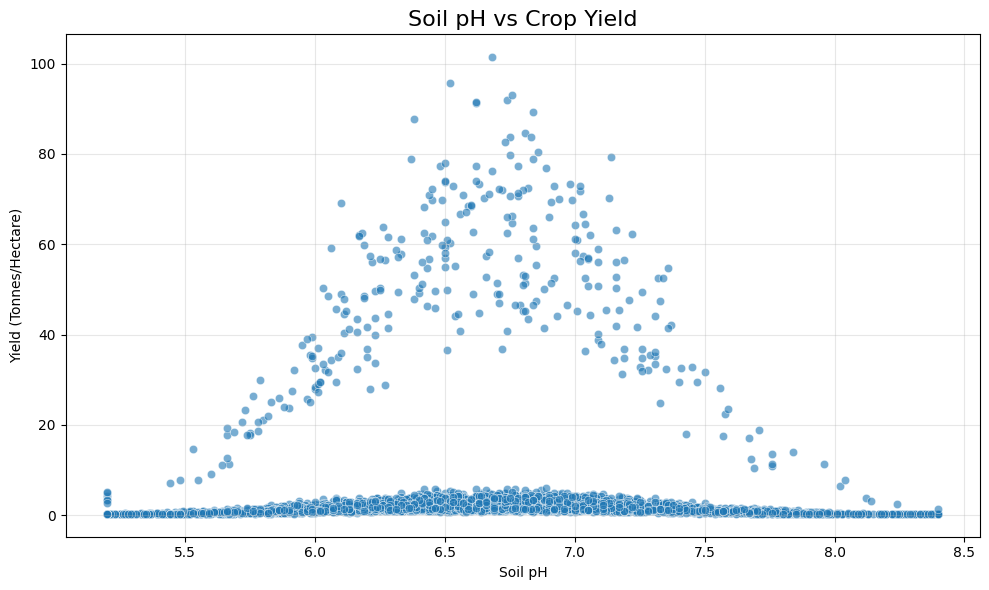

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="Soil_pH",
    y="Yield_Tonnes_Ha",
    alpha=0.6
)

plt.title("Soil pH vs Crop Yield", fontsize=16)
plt.xlabel("Soil pH")
plt.ylabel("Yield (Tonnes/Hectare)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
soil_ph_yield_corr = clean_df[
    ["Soil_pH", "Yield_Tonnes_Ha"]
].corr().iloc[0, 1]

print(
    f"Correlation between Soil pH and Yield: "
    f"{soil_ph_yield_corr:.3f}"
)

Correlation between Soil pH and Yield: -0.022


In [ ]:
total_revenue = clean_df["Revenue_INR"].sum()
total_cost = clean_df["Total_Cost_INR"].sum()
total_profit = clean_df["Profit_INR"].sum()

profitable_farms = (clean_df["Profit_INR"] >= 0).sum()
loss_making_farms = (clean_df["Profit_INR"] < 0).sum()

print("OVERALL PROFITABILITY SUMMARY")
print("=" * 50)
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Cost: ₹{total_cost:,.2f}")
print(f"Total Profit/Loss: ₹{total_profit:,.2f}")
print(f"Profitable Farms: {profitable_farms}")
print(f"Loss-Making Farms: {loss_making_farms}")

OVERALL PROFITABILITY SUMMARY
Total Revenue: ₹2,551,440,192.00
Total Cost: ₹2,105,214,332.00
Total Profit/Loss: ₹446,225,860.00
Profitable Farms: 2034
Loss-Making Farms: 1966


In [ ]:
crop_profit = (
    clean_df.groupby("Crop")["Profit_INR"]
    .sum()
    .sort_values(ascending=False)
)

print("CROP-WISE TOTAL PROFIT")
print("=" * 50)
display(crop_profit)

CROP-WISE TOTAL PROFIT


,Profit_INR
Crop,
Chilli,309361877
Sugarcane,249242336
Cotton,63269833
Groundnut,19019843
Pulses,-2102074
Maize,-46272058
Rice,-70527318
Wheat,-75766579


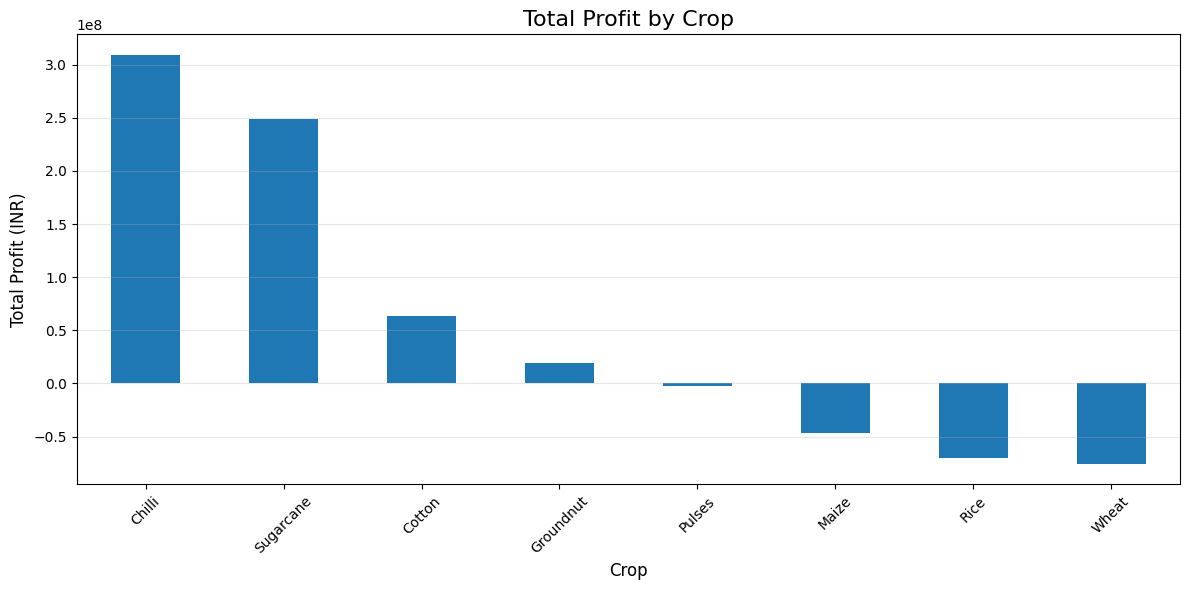

In [ ]:
plt.figure(figsize=(12, 6))

crop_profit.plot(kind="bar")

plt.title("Total Profit by Crop", fontsize=16)
plt.xlabel("Crop", fontsize=12)
plt.ylabel("Total Profit (INR)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
most_profitable_crop = crop_profit.idxmax()
highest_crop_profit = crop_profit.max()

print("MOST PROFITABLE CROP")
print("=" * 50)
print(f"Crop: {most_profitable_crop}")
print(f"Total Profit: ₹{highest_crop_profit:,.2f}")

MOST PROFITABLE CROP
Crop: Chilli
Total Profit: ₹309,361,877.00


In [ ]:
season_profit = (
    clean_df.groupby("Season")["Profit_INR"]
    .sum()
    .sort_values(ascending=False)
)

print("SEASON-WISE TOTAL PROFIT")
print("=" * 50)
display(season_profit)

SEASON-WISE TOTAL PROFIT


,Profit_INR
Season,
Kharif,318289158
Rabi,142670768
Zaid,-14734066


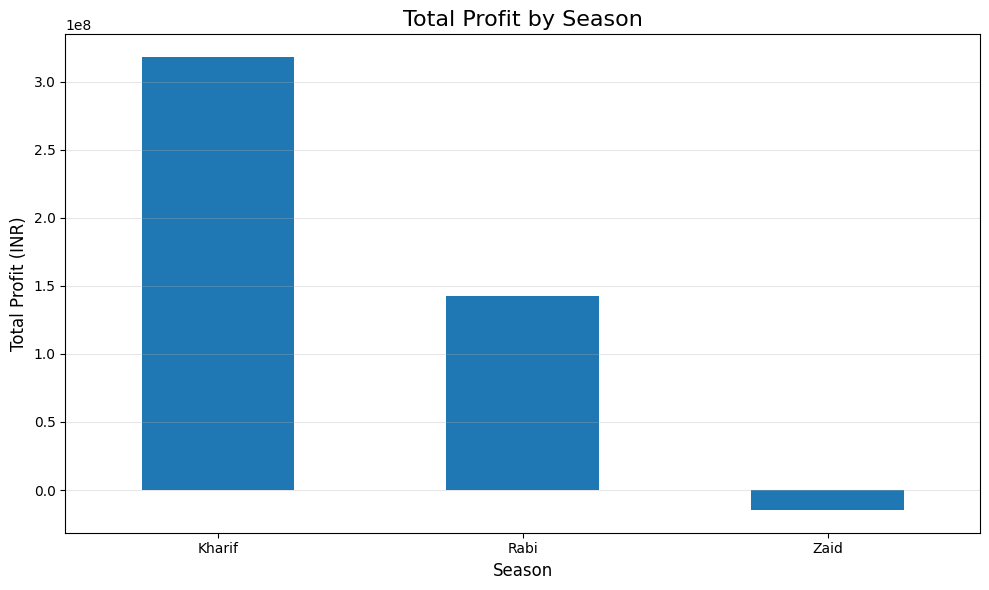

In [ ]:
plt.figure(figsize=(10, 6))

season_profit.plot(kind="bar")

plt.title("Total Profit by Season", fontsize=16)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Total Profit (INR)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
most_profitable_season = season_profit.idxmax()
highest_season_profit = season_profit.max()

print("MOST PROFITABLE SEASON")
print("=" * 50)
print(f"Season: {most_profitable_season}")
print(f"Total Profit: ₹{highest_season_profit:,.2f}")

MOST PROFITABLE SEASON
Season: Kharif
Total Profit: ₹318,289,158.00


In [ ]:
crop_margin = (
    clean_df.groupby("Crop")["Profit_Margin_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("AVERAGE PROFIT MARGIN BY CROP")
print("=" * 50)
display(crop_margin)

AVERAGE PROFIT MARGIN BY CROP


,Profit_Margin_pct
Crop,
Chilli,33.776597
Sugarcane,27.346809
Cotton,-8.229093
Groundnut,-28.658537
Pulses,-36.484144
Maize,-81.539685
Wheat,-91.702553
Rice,-99.368087


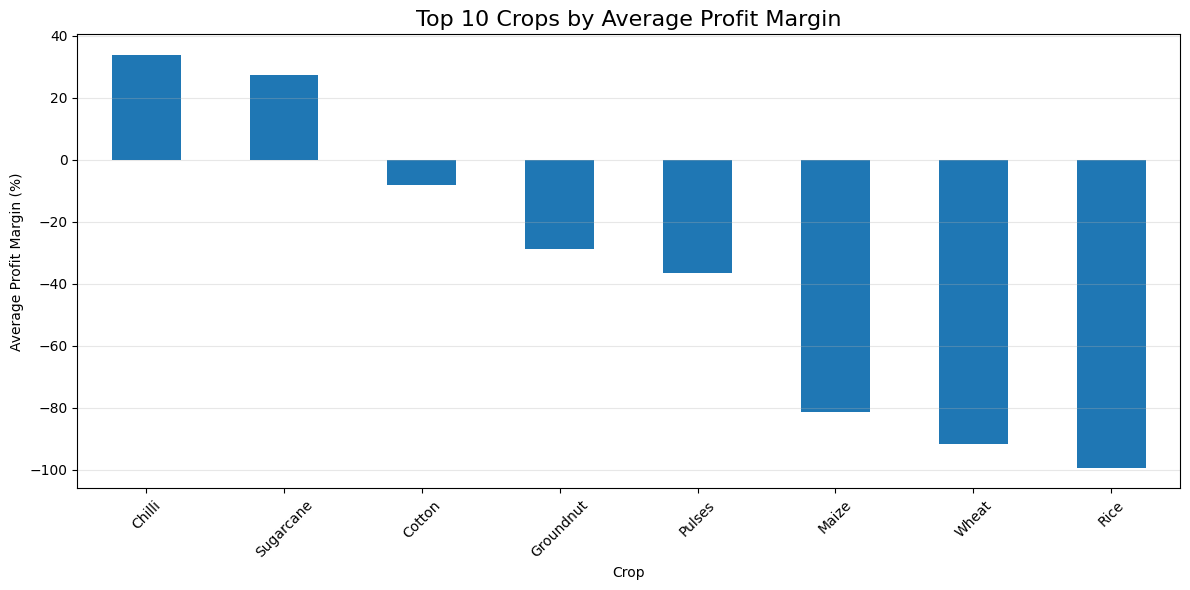

In [ ]:
top_10_margin_crops = crop_margin.head(10)

plt.figure(figsize=(12, 6))

top_10_margin_crops.plot(kind="bar")

plt.title("Top 10 Crops by Average Profit Margin", fontsize=16)
plt.xlabel("Crop")
plt.ylabel("Average Profit Margin (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_margin_crop = crop_margin.idxmax()
best_margin = crop_margin.max()

print("CROP WITH HIGHEST AVERAGE PROFIT MARGIN")
print("=" * 50)
print(f"Crop: {best_margin_crop}")
print(f"Average Profit Margin: {best_margin:.2f}%")

CROP WITH HIGHEST AVERAGE PROFIT MARGIN
Crop: Chilli
Average Profit Margin: 33.78%


In [ ]:
crop_water_efficiency = (
    clean_df.groupby("Crop")["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
)

print("CROP-WISE WATER EFFICIENCY")
print("=" * 50)
display(crop_water_efficiency)

CROP-WISE WATER EFFICIENCY


,Water_Efficiency_t_per_1000m3
Crop,
Sugarcane,30.477672
Maize,5.602995
Wheat,4.628393
Groundnut,3.154795
Chilli,2.947709
Pulses,2.896504
Rice,1.946112
Cotton,1.938016


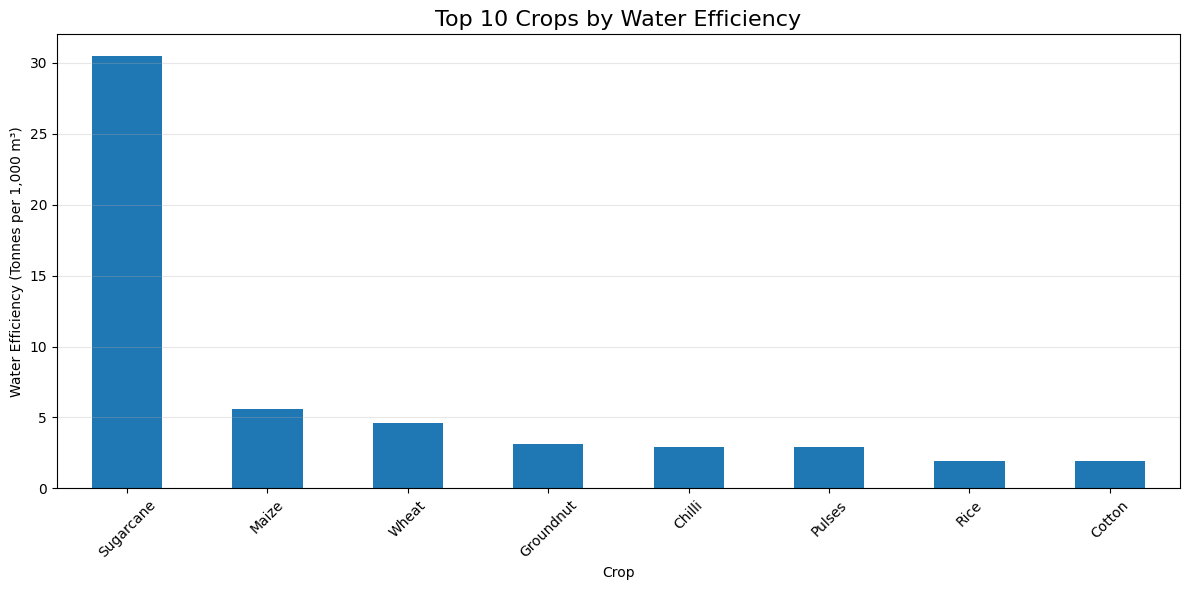

In [ ]:
top_10_water_efficient_crops = crop_water_efficiency.head(10)

plt.figure(figsize=(12, 6))

top_10_water_efficient_crops.plot(kind="bar")

plt.title("Top 10 Crops by Water Efficiency", fontsize=16)
plt.xlabel("Crop")
plt.ylabel("Water Efficiency (Tonnes per 1,000 m³)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_water_crop = crop_water_efficiency.idxmax()
best_water_efficiency = crop_water_efficiency.max()

print("MOST WATER-EFFICIENT CROP")
print("=" * 50)
print(f"Crop: {best_water_crop}")
print(f"Water Efficiency: {best_water_efficiency:.2f} tonnes per 1,000 m³")

MOST WATER-EFFICIENT CROP
Crop: Sugarcane
Water Efficiency: 30.48 tonnes per 1,000 m³


In [ ]:
crop_risk = (
    clean_df.groupby("Crop")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("CROP-WISE DISEASE & PEST RISK")
print("=" * 50)
display(crop_risk)


CROP-WISE DISEASE & PEST RISK


,Disease_Pest_Risk_pct
Crop,
Wheat,47.854723
Pulses,46.570161
Rice,46.495797
Groundnut,46.289151
Chilli,46.062136
Cotton,45.974606
Maize,45.539564
Sugarcane,45.403934


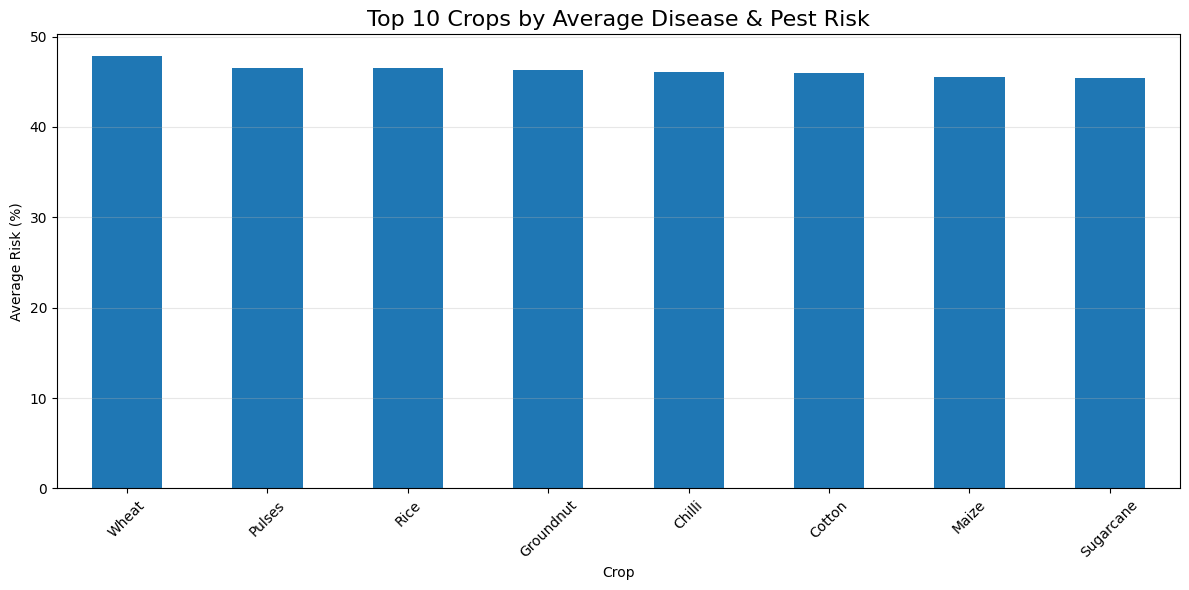

In [ ]:
top_10_risk_crops = crop_risk.head(10)

plt.figure(figsize=(12, 6))

top_10_risk_crops.plot(kind="bar")

plt.title("Top 10 Crops by Average Disease & Pest Risk", fontsize=16)
plt.xlabel("Crop")
plt.ylabel("Average Risk (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
highest_risk_crop = crop_risk.idxmax()
highest_risk = crop_risk.max()

print("HIGHEST-RISK CROP")
print("=" * 50)
print(f"Crop: {highest_risk_crop}")
print(f"Average Disease/Pest Risk: {highest_risk:.2f}%")

HIGHEST-RISK CROP
Crop: Wheat
Average Disease/Pest Risk: 47.85%


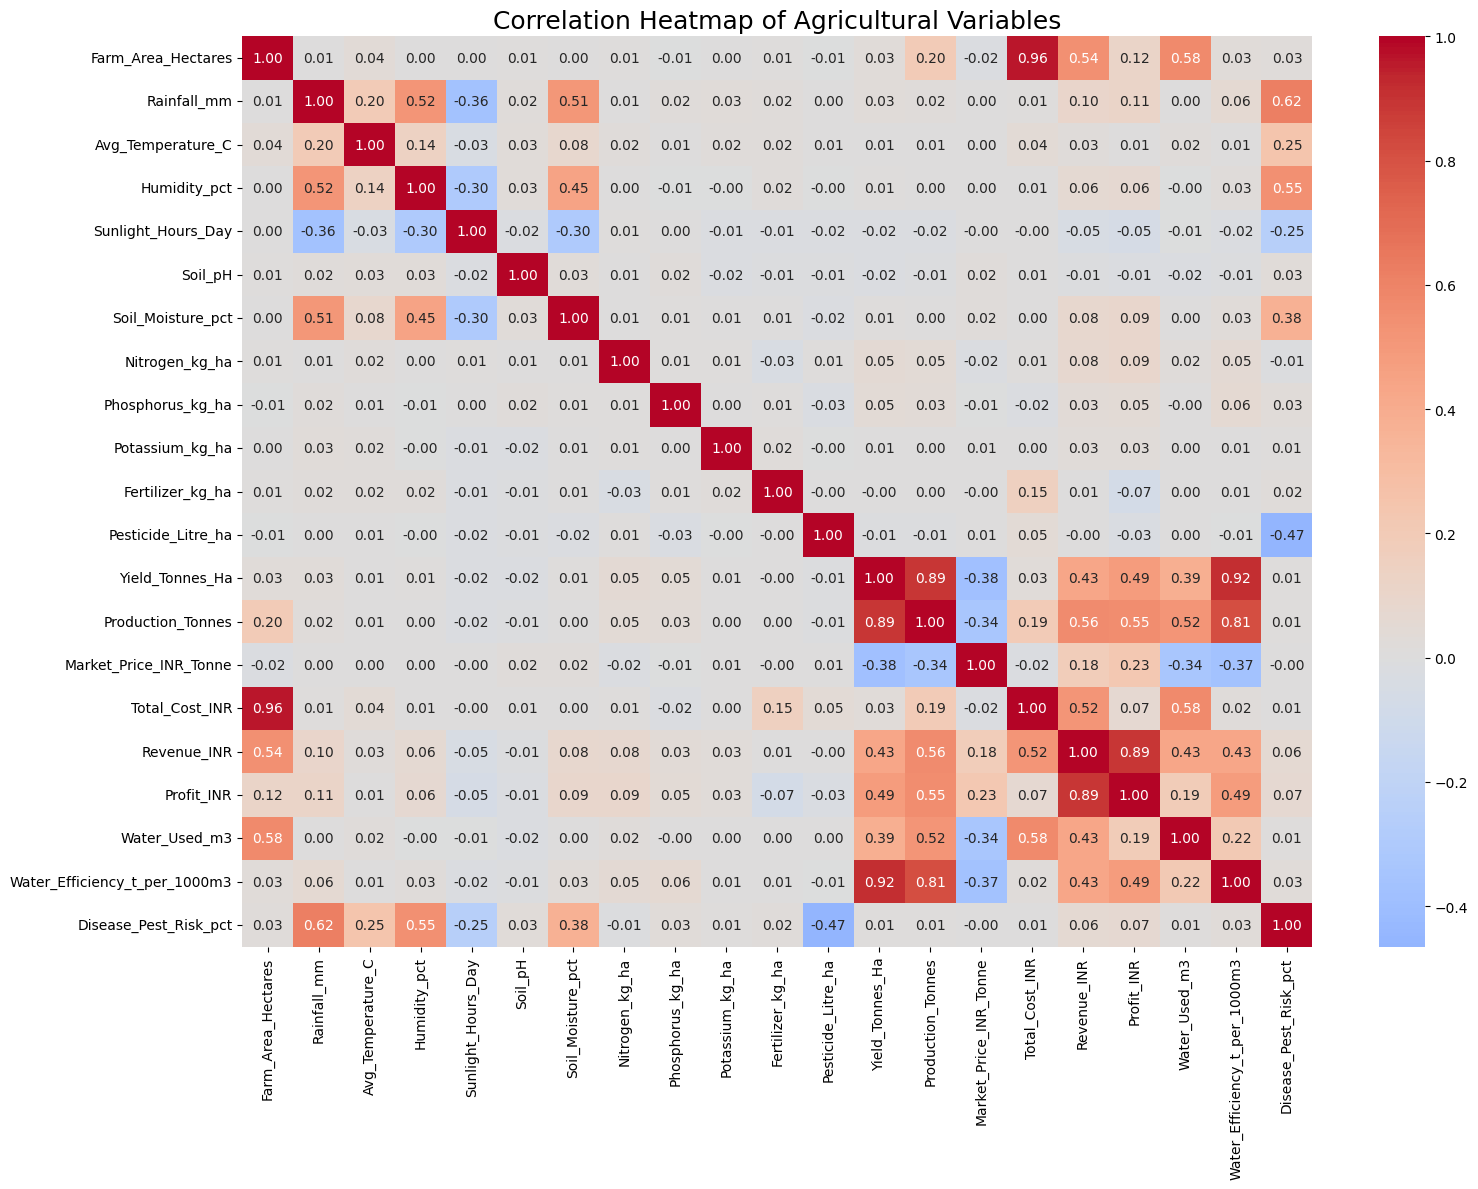

In [ ]:
correlation_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = clean_df[correlation_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Agricultural Variables", fontsize=18)
plt.tight_layout()
plt.show()

In [ ]:
corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

strong_correlations = (
    corr_pairs
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("STRONGEST VARIABLE RELATIONSHIPS")
print("=" * 60)

display(strong_correlations.head(10))

STRONGEST VARIABLE RELATIONSHIPS


Farm_Area_Hectares  Total_Cost_INR                   0.962211
Yield_Tonnes_Ha     Water_Efficiency_t_per_1000m3    0.915738
Revenue_INR         Profit_INR                       0.887331
Yield_Tonnes_Ha     Production_Tonnes                0.885713
Production_Tonnes   Water_Efficiency_t_per_1000m3    0.812143
Rainfall_mm         Disease_Pest_Risk_pct            0.621762
Farm_Area_Hectares  Water_Used_m3                    0.576015
Total_Cost_INR      Water_Used_m3                    0.575978
Production_Tonnes   Revenue_INR                      0.563505
                    Profit_INR                       0.554172
dtype: float64

In [ ]:
print("=" * 70)
print("🌾 SEASONAL AGRICULTURE PERFORMANCE — KEY INSIGHTS")
print("=" * 70)

print(f"\n1. Highest-Producing Season:")
print(f"   {season_production.idxmax()} — "
      f"{season_production.max():,.2f} tonnes")

print(f"\n2. Highest-Producing Crop:")
print(f"   {crop_production.idxmax()} — "
      f"{crop_production.max():,.2f} tonnes")

print(f"\n3. Highest-Yielding Crop:")
print(f"   {crop_yield.idxmax()} — "
      f"{crop_yield.max():.2f} tonnes/hectare")

print(f"\n4. Highest-Producing State:")
print(f"   {state_production.idxmax()} — "
      f"{state_production.max():,.2f} tonnes")

print(f"\n5. Most Profitable Crop:")
print(f"   {crop_profit.idxmax()} — "
      f"₹{crop_profit.max():,.2f}")

print(f"\n6. Most Profitable Season:")
print(f"   {season_profit.idxmax()} — "
      f"₹{season_profit.max():,.2f}")

print(f"\n7. Highest Profit-Margin Crop:")
print(f"   {crop_margin.idxmax()} — "
      f"{crop_margin.max():.2f}%")

print(f"\n8. Most Water-Efficient Crop:")
print(f"   {crop_water_efficiency.idxmax()} — "
      f"{crop_water_efficiency.max():.2f} tonnes per 1,000 m³")

print(f"\n9. Total Production:")
print(f"   {clean_df['Production_Tonnes'].sum():,.2f} tonnes")

print(f"\n10. Overall Profit/Loss:")
print(f"   ₹{clean_df['Profit_INR'].sum():,.2f}")

print("\n" + "=" * 70)

🌾 SEASONAL AGRICULTURE PERFORMANCE — KEY INSIGHTS

1. Highest-Producing Season:
   Kharif — 82,387.61 tonnes

2. Highest-Producing Crop:
   Sugarcane — 119,685.97 tonnes

3. Highest-Yielding Crop:
   Sugarcane — 46.93 tonnes/hectare

4. Highest-Producing State:
   Punjab — 25,280.82 tonnes

5. Most Profitable Crop:
   Chilli — ₹309,361,877.00

6. Most Profitable Season:
   Kharif — ₹318,289,158.00

7. Highest Profit-Margin Crop:
   Chilli — 33.78%

8. Most Water-Efficient Crop:
   Sugarcane — 30.48 tonnes per 1,000 m³

9. Total Production:
   172,984.84 tonnes

10. Overall Profit/Loss:
   ₹446,225,860.00



In [ ]:
print("=" * 70)
print("🌱 EVIDENCE-BASED AGRICULTURAL RECOMMENDATIONS")
print("=" * 70)

print("\n1. SEASONAL STRATEGY")
print(f"   {season_production.idxmax()} has the highest total production "
      f"({season_production.max():,.2f} tonnes).")
print("   → Prioritize planning and resource allocation for this season.")

print("\n2. PROFITABILITY STRATEGY")
print(f"   {season_profit.idxmax()} generates the highest total profit "
      f"(₹{season_profit.max():,.2f}).")
print("   → Analyze successful practices in this season for replication.")

print("\n3. CROP PROFITABILITY")
print(f"   {crop_profit.idxmax()} generates the highest total profit "
      f"(₹{crop_profit.max():,.2f}).")
print(f"   → Study its cost, price and production characteristics "
      f"for profitable crop planning.")

print("\n4. WATER MANAGEMENT")
print(f"   {crop_water_efficiency.idxmax()} has the highest average "
      f"water efficiency "
      f"({crop_water_efficiency.max():.2f} tonnes per 1,000 m³).")
print("   → Consider water efficiency when evaluating crop choices.")

print("\n5. REGIONAL FOCUS")
print(f"   {state_production.idxmax()} has the highest total production "
      f"({state_production.max():,.2f} tonnes).")
print("   → Examine regional practices and resource conditions "
      "associated with high production.")

print("\n6. RISK MONITORING")
print(f"   {crop_risk.idxmax()} has the highest average disease/pest "
      f"risk ({crop_risk.max():.2f}%).")
print("   → Higher-risk crop categories should receive closer "
      "monitoring and preventive planning.")

print("\n7. DATA-DRIVEN PLANNING")
print("   → Combine production, yield, profitability, water efficiency "
      "and risk indicators rather than relying on a single metric.")

print("\n" + "=" * 70)

🌱 EVIDENCE-BASED AGRICULTURAL RECOMMENDATIONS

1. SEASONAL STRATEGY
   Kharif has the highest total production (82,387.61 tonnes).
   → Prioritize planning and resource allocation for this season.

2. PROFITABILITY STRATEGY
   Kharif generates the highest total profit (₹318,289,158.00).
   → Analyze successful practices in this season for replication.

3. CROP PROFITABILITY
   Chilli generates the highest total profit (₹309,361,877.00).
   → Study its cost, price and production characteristics for profitable crop planning.

4. WATER MANAGEMENT
   Sugarcane has the highest average water efficiency (30.48 tonnes per 1,000 m³).
   → Consider water efficiency when evaluating crop choices.

5. REGIONAL FOCUS
   Punjab has the highest total production (25,280.82 tonnes).
   → Examine regional practices and resource conditions associated with high production.

6. RISK MONITORING
   Wheat has the highest average disease/pest risk (47.85%).
   → Higher-risk crop categories should receive closer

In [ ]:
print("=" * 70)
print("🌾 PROJECT CONCLUSION")
print("=" * 70)

print("""
The Seasonal Agriculture Performance Analysis project examined
agricultural performance across seasons, crops and states using
production, yield, environmental, profitability, water-efficiency
and disease/pest-risk indicators.

The analysis identified differences in agricultural performance
across seasons and regions and highlighted important relationships
between production, yield, profitability and resource efficiency.

The findings demonstrate how data analytics and visualization can
support evidence-based agricultural planning by helping identify
high-performing crops, productive seasons, profitable opportunities,
resource-efficient practices and areas requiring greater risk
attention.

The project provides a data-driven framework that can be extended
with additional historical data, real-time agricultural information,
weather data and predictive analytics in future work.
""")

print("=" * 70)


🌾 PROJECT CONCLUSION

The Seasonal Agriculture Performance Analysis project examined
agricultural performance across seasons, crops and states using
production, yield, environmental, profitability, water-efficiency
and disease/pest-risk indicators.

The analysis identified differences in agricultural performance
across seasons and regions and highlighted important relationships
between production, yield, profitability and resource efficiency.

The findings demonstrate how data analytics and visualization can
support evidence-based agricultural planning by helping identify
high-performing crops, productive seasons, profitable opportunities,
resource-efficient practices and areas requiring greater risk
attention.

The project provides a data-driven framework that can be extended
with additional historical data, real-time agricultural information,
weather data and predictive analytics in future work.



# 🌾 Final Project Summary

## Seasonal Agriculture Performance Analysis

### Key Analytical Areas

- Seasonal Production Performance
- Crop-wise Production and Yield
- State-wise Agricultural Performance
- Crop × Season Analysis
- Environmental Factor Analysis
- Profitability Analysis
- Water Efficiency Analysis
- Disease & Pest Risk Analysis
- Correlation Analysis

### Key Outcomes

The analysis provides data-driven insights into agricultural
production, yield, profitability, resource efficiency and
risk patterns across crops, seasons and states.

### Technology

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

### Dataset

4,000 agricultural farm records with 28 original variables,
extended through feature engineering for comprehensive analysis.

### Note

The dataset does not contain a Year column. Therefore, the
analysis focuses on seasonal, crop-wise, state-wise,
environmental, profitability, water-efficiency and risk patterns
rather than year-over-year trends.

In [ ]:
# ============================================================
# STEP 22.1 — FINAL DATA VALIDATION
# ============================================================

print("=" * 70)
print("🔍 FINAL DATA VALIDATION")
print("=" * 70)

print("\nDataset Shape:")
print(clean_df.shape)

print("\nMissing Values:")
print(clean_df.isnull().sum()[clean_df.isnull().sum() > 0])

print("\nDuplicate Rows:")
print(clean_df.duplicated().sum())

print("\nNegative Values in Key Agricultural Variables:")

key_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

negative_check = {}

for col in key_columns:
    count = (clean_df[col] < 0).sum()
    if count > 0:
        negative_check[col] = count

print(negative_check)

print("\nProfit values below zero are retained because")
print("negative profit represents legitimate loss-making farms.")

print("\n" + "=" * 70)
print("✅ FINAL VALIDATION COMPLETE")
print("=" * 70)

🔍 FINAL DATA VALIDATION

Dataset Shape:
(4000, 32)

Missing Values:
Series([], dtype: int64)

Duplicate Rows:
0

Negative Values in Key Agricultural Variables:
{}

Profit values below zero are retained because
negative profit represents legitimate loss-making farms.

✅ FINAL VALIDATION COMPLETE


In [ ]:
# ============================================================
# STEP 23.1 — OUTLIER DETECTION USING IQR
# ============================================================

print("=" * 70)
print("📊 OUTLIER ANALYSIS — IQR METHOD")
print("=" * 70)

outlier_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

outlier_summary = []

for col in outlier_columns:

    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = clean_df[
        (clean_df[col] < lower_bound) |
        (clean_df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": (len(outliers) / len(clean_df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.sort_values(
    "Outlier_Count",
    ascending=False
)

display(outlier_df.round(2))

print("\n" + "=" * 70)
print("✅ OUTLIER DETECTION COMPLETE")
print("=" * 70)

📊 OUTLIER ANALYSIS — IQR METHOD


,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-148731.75,216187.75,-696111.00,763567.00,404,10.10
14,Production_Tonnes,5.02,24.36,-23.98,53.36,333,8.33
13,Yield_Tonnes_Ha,1.05,2.84,-1.63,5.52,304,7.60
19,Water_Used_m3,2268.75,7829.75,-6072.75,16171.25,276,6.90
17,Revenue_INR,207517.25,836874.75,-736519.00,1780911.00,240,6.00
9,Potassium_kg_ha,86.20,123.60,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,6.60,8.10,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,46.20,69.40,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,143.98,227.20,19.14,352.04,15,0.38
7,Nitrogen_kg_ha,98.50,141.22,34.41,205.31,10,0.25



✅ OUTLIER DETECTION COMPLETE


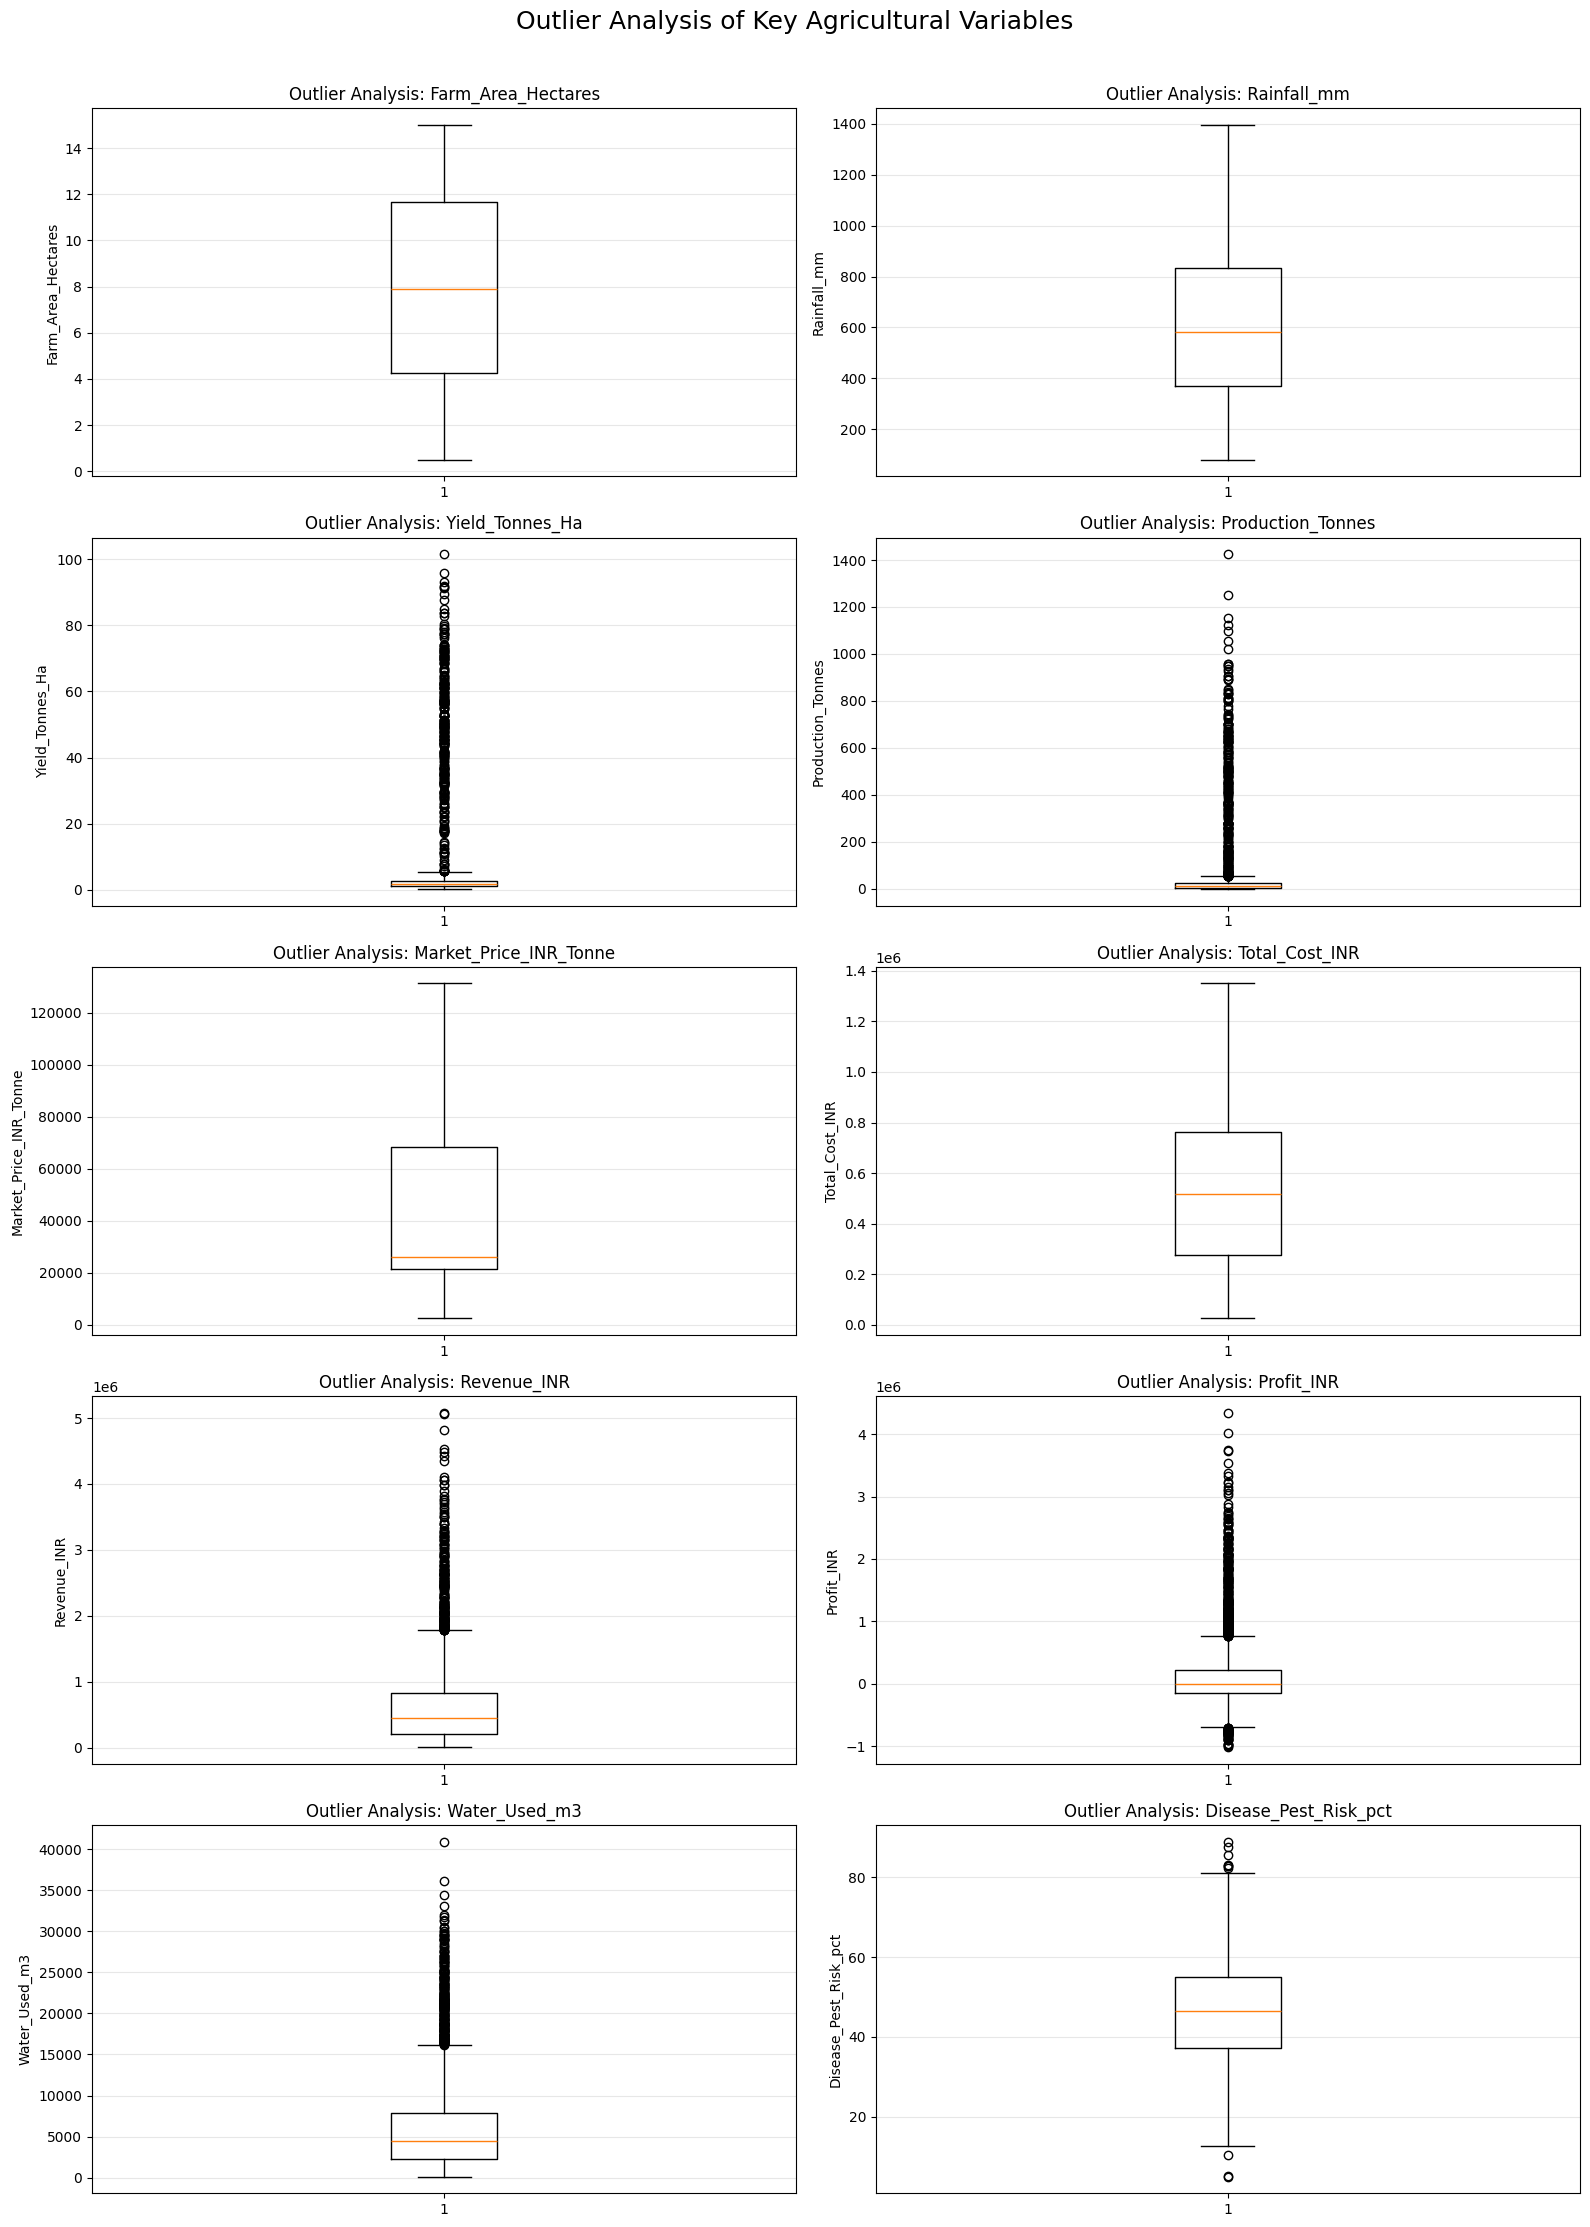

In [ ]:
# ============================================================
# STEP 23.2 — IMPORTANT OUTLIER VISUALIZATION
# ============================================================

important_outlier_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

fig, axes = plt.subplots(
    5, 2,
    figsize=(16, 22)
)

axes = axes.flatten()

for i, col in enumerate(important_outlier_columns):

    axes[i].boxplot(
        clean_df[col].dropna(),
        vert=True
    )

    axes[i].set_title(
        f"Outlier Analysis: {col}",
        fontsize=12
    )

    axes[i].set_ylabel(col)

    axes[i].grid(
        axis="y",
        alpha=0.3
    )

plt.suptitle(
    "Outlier Analysis of Key Agricultural Variables",
    fontsize=18,
    y=1.01
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 23.3 — OUTLIER DECISION
# ============================================================

print("=" * 70)
print("📌 OUTLIER HANDLING DECISION")
print("=" * 70)

print("""
Outliers are not automatically removed from this dataset.

Agricultural data can naturally contain extreme observations,
such as:

• Very large farms
• High-production farms
• Extreme rainfall conditions
• High or low market prices
• Very high profits or losses
• High water consumption
• High disease/pest risk

Therefore, detected outliers are treated as potential valid
observations unless a clear data-quality problem is identified.

Decision:
✅ Retain detected outliers
✅ Do not perform arbitrary outlier deletion
✅ Use robust interpretation when analyzing extreme values
""")

print("=" * 70)
print("✅ OUTLIER HANDLING DECISION COMPLETE")
print("=" * 70)

📌 OUTLIER HANDLING DECISION

Outliers are not automatically removed from this dataset.

Agricultural data can naturally contain extreme observations,
such as:

• Very large farms
• High-production farms
• Extreme rainfall conditions
• High or low market prices
• Very high profits or losses
• High water consumption
• High disease/pest risk

Therefore, detected outliers are treated as potential valid
observations unless a clear data-quality problem is identified.

Decision:
✅ Retain detected outliers
✅ Do not perform arbitrary outlier deletion
✅ Use robust interpretation when analyzing extreme values

✅ OUTLIER HANDLING DECISION COMPLETE


In [ ]:
# ============================================================
# STEP 24 — FINAL KPI SUMMARY
# ============================================================

print("=" * 80)
print("🌾 SEASONAL AGRICULTURE PERFORMANCE — FINAL KPI SUMMARY")
print("=" * 80)

# Basic KPIs
total_farms = clean_df["Farm_ID"].nunique()
total_production = clean_df["Production_Tonnes"].sum()
average_yield = clean_df["Yield_Tonnes_Ha"].mean()

# Financial KPIs
total_revenue = clean_df["Revenue_INR"].sum()
total_cost = clean_df["Total_Cost_INR"].sum()
total_profit = clean_df["Profit_INR"].sum()

profitable_farms = (clean_df["Profit_INR"] >= 0).sum()
loss_making_farms = (clean_df["Profit_INR"] < 0).sum()

# Resource & risk KPIs
average_water_efficiency = clean_df[
    "Water_Efficiency_t_per_1000m3"
].mean()

average_risk = clean_df[
    "Disease_Pest_Risk_pct"
].mean()

# Best performers
best_season = season_production.idxmax()
best_state = state_production.idxmax()
best_profit_crop = crop_profit.idxmax()
best_water_crop = crop_water_efficiency.idxmax()

print(f"\n🌾 Total Farms              : {total_farms:,}")
print(f"📦 Total Production         : {total_production:,.2f} tonnes")
print(f"📈 Average Yield            : {average_yield:.2f} tonnes/hectare")

print("\n💰 FINANCIAL PERFORMANCE")
print(f"   Total Revenue            : ₹{total_revenue:,.2f}")
print(f"   Total Cost               : ₹{total_cost:,.2f}")
print(f"   Total Profit/Loss        : ₹{total_profit:,.2f}")
print(f"   Profitable Farms         : {profitable_farms:,}")
print(f"   Loss-Making Farms        : {loss_making_farms:,}")

print("\n💧 RESOURCE & RISK")
print(f"   Avg Water Efficiency     : "
      f"{average_water_efficiency:.2f} tonnes / 1,000 m³")
print(f"   Avg Disease/Pest Risk    : "
      f"{average_risk:.2f}%")

print("\n🏆 TOP PERFORMERS")
print(f"   Best Production Season   : {best_season}")
print(f"   Highest-Producing State  : {best_state}")
print(f"   Most Profitable Crop     : {best_profit_crop}")
print(f"   Most Water-Efficient Crop: {best_water_crop}")

print("\n" + "=" * 80)
print("✅ FINAL KPI SUMMARY COMPLETE")
print("=" * 80)

🌾 SEASONAL AGRICULTURE PERFORMANCE — FINAL KPI SUMMARY

🌾 Total Farms              : 4,000
📦 Total Production         : 172,984.84 tonnes
📈 Average Yield            : 5.26 tonnes/hectare

💰 FINANCIAL PERFORMANCE
   Total Revenue            : ₹2,551,440,192.00
   Total Cost               : ₹2,105,214,332.00
   Total Profit/Loss        : ₹446,225,860.00
   Profitable Farms         : 2,034
   Loss-Making Farms        : 1,966

💧 RESOURCE & RISK
   Avg Water Efficiency     : 5.39 tonnes / 1,000 m³
   Avg Disease/Pest Risk    : 46.37%

🏆 TOP PERFORMERS
   Best Production Season   : Kharif
   Highest-Producing State  : Punjab
   Most Profitable Crop     : Chilli
   Most Water-Efficient Crop: Sugarcane

✅ FINAL KPI SUMMARY COMPLETE


/tmp/ipykernel_1874/382920416.py:90: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


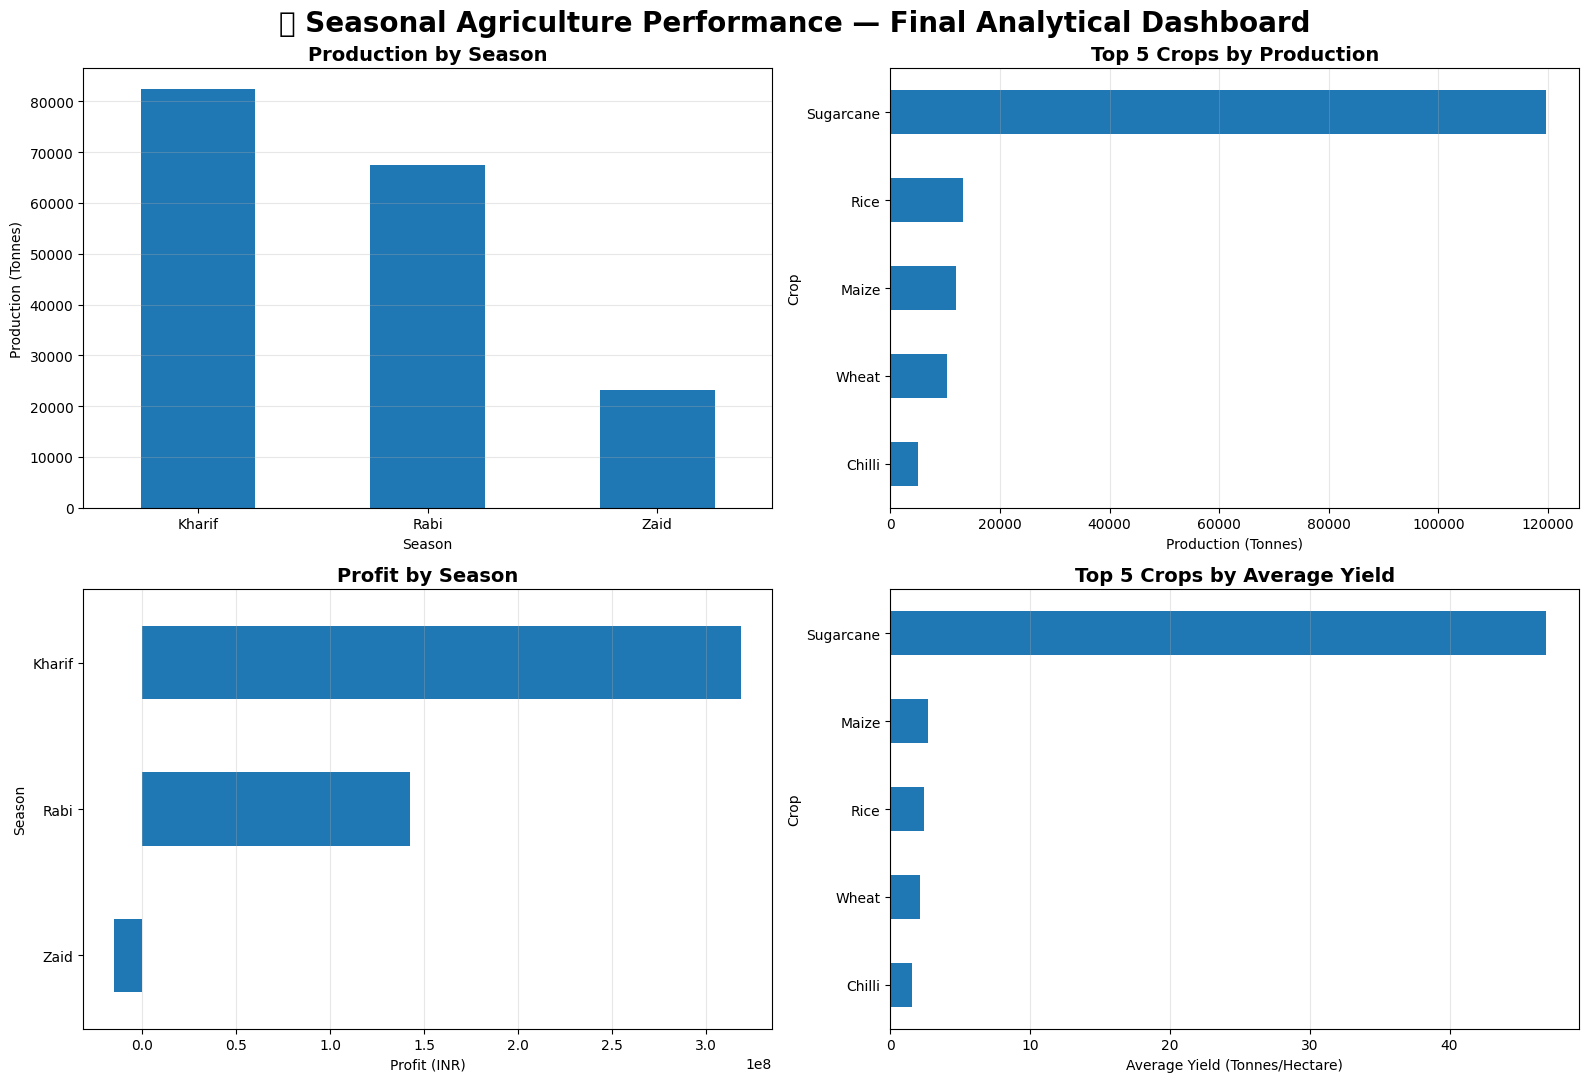

In [ ]:
# ============================================================
# STEP 25 — FINAL ANALYTICAL DASHBOARD
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ------------------------------------------------------------
# 1. Production by Season
# ------------------------------------------------------------

season_production.plot(
    kind="bar",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Production by Season",
    fontsize=14,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Season")
axes[0, 0].set_ylabel("Production (Tonnes)")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].grid(axis="y", alpha=0.3)


# ------------------------------------------------------------
# 2. Top 5 Crops by Production
# ------------------------------------------------------------

crop_production.head(5).sort_values().plot(
    kind="barh",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Top 5 Crops by Production",
    fontsize=14,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Production (Tonnes)")
axes[0, 1].set_ylabel("Crop")
axes[0, 1].grid(axis="x", alpha=0.3)


# ------------------------------------------------------------
# 3. Profit by Season
# ------------------------------------------------------------

season_profit.sort_values().plot(
    kind="barh",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Profit by Season",
    fontsize=14,
    fontweight="bold"
)
axes[1, 0].set_xlabel("Profit (INR)")
axes[1, 0].set_ylabel("Season")
axes[1, 0].grid(axis="x", alpha=0.3)


# ------------------------------------------------------------
# 4. Top 5 Crops by Average Yield
# ------------------------------------------------------------

crop_yield.head(5).sort_values().plot(
    kind="barh",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Top 5 Crops by Average Yield",
    fontsize=14,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Average Yield (Tonnes/Hectare)")
axes[1, 1].set_ylabel("Crop")
axes[1, 1].grid(axis="x", alpha=0.3)


plt.suptitle(
    "🌾 Seasonal Agriculture Performance — Final Analytical Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 26.1 — PREPARE DATA FOR YIELD PREDICTION
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Target variable
target = "Yield_Tonnes_Ha"

# Predictor variables
features = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Irrigation_Method",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Disease_Pest_Risk_pct",
    "Season",
    "Crop",
    "State"
]

X = clean_df[features].copy()
y = clean_df[target].copy()

print("=" * 70)
print("🌱 YIELD PREDICTION DATASET")
print("=" * 70)

print("\nFeatures:", len(features))
print("Target:", target)
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nCategorical Features:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nNumerical Features:")
print(X.select_dtypes(exclude="object").columns.tolist())

print("\nMissing Values in X:")
print(X.isnull().sum()[X.isnull().sum() > 0])

print("\nMissing Values in Target:")
print(y.isnull().sum())

print("=" * 70)
print("✅ ML DATASET PREPARED")
print("=" * 70)

🌱 YIELD PREDICTION DATASET

Features: 18
Target: Yield_Tonnes_Ha
X Shape: (4000, 18)
y Shape: (4000,)

Categorical Features:
['Irrigation_Method', 'Season', 'Crop', 'State']

Numerical Features:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Disease_Pest_Risk_pct']

Missing Values in X:
Series([], dtype: int64)

Missing Values in Target:
0
✅ ML DATASET PREPARED


In [ ]:
# ============================================================
# STEP 26.2 — TRAIN RANDOM FOREST YIELD PREDICTION MODEL
# ============================================================

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        )
    ]
)


# Random Forest model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# Complete pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("=" * 70)
print("🌱 RANDOM FOREST YIELD PREDICTION")
print("=" * 70)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

# Train model
rf_pipeline.fit(X_train, y_train)

print("\n✅ Model training completed!")

# Predictions
y_pred = rf_pipeline.predict(X_test)

print("✅ Predictions generated!")

print("=" * 70)

🌱 RANDOM FOREST YIELD PREDICTION

Training samples: 3200
Testing samples : 800

✅ Model training completed!
✅ Predictions generated!


In [ ]:
# ============================================================
# STEP 26.2 — TRAIN RANDOM FOREST YIELD PREDICTION MODEL
# ============================================================

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        )
    ]
)


# Random Forest model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# Complete pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("=" * 70)
print("🌱 RANDOM FOREST YIELD PREDICTION")
print("=" * 70)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

# Train model
rf_pipeline.fit(X_train, y_train)

print("\n✅ Model training completed!")

# Predictions
y_pred = rf_pipeline.predict(X_test)

print("✅ Predictions generated!")

print("=" * 70)

🌱 RANDOM FOREST YIELD PREDICTION

Training samples: 3200
Testing samples : 800

✅ Model training completed!
✅ Predictions generated!


In [ ]:
# ============================================================
# STEP 26.2 — TRAIN RANDOM FOREST YIELD PREDICTION MODEL
# ============================================================

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "encoder",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        )
    ]
)


# Random Forest model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# Complete pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("=" * 70)
print("🌱 RANDOM FOREST YIELD PREDICTION")
print("=" * 70)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

# Train model
rf_pipeline.fit(X_train, y_train)

print("\n✅ Model training completed!")

# Predictions
y_pred = rf_pipeline.predict(X_test)

print("✅ Predictions generated!")

print("=" * 70)

🌱 RANDOM FOREST YIELD PREDICTION

Training samples: 3200
Testing samples : 800

✅ Model training completed!
✅ Predictions generated!


In [ ]:
# ============================================================
# STEP 26.3 — MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("=" * 70)
print("📊 YIELD PREDICTION MODEL — EVALUATION")
print("=" * 70)

print(f"\nMean Absolute Error (MAE)  : {mae:.4f}")
print(f"Root Mean Squared Error    : {rmse:.4f}")
print(f"R² Score                   : {r2:.4f}")

print("\nInterpretation:")
print(f"On average, predictions differ from actual yield by "
      f"approximately {mae:.2f} tonnes/hectare.")

print(f"The model explains approximately "
      f"{r2 * 100:.2f}% of the variation in yield.")

print("=" * 70)

📊 YIELD PREDICTION MODEL — EVALUATION

Mean Absolute Error (MAE)  : 0.7412
Root Mean Squared Error    : 2.6168
R² Score                   : 0.9645

Interpretation:
On average, predictions differ from actual yield by approximately 0.74 tonnes/hectare.
The model explains approximately 96.45% of the variation in yield.


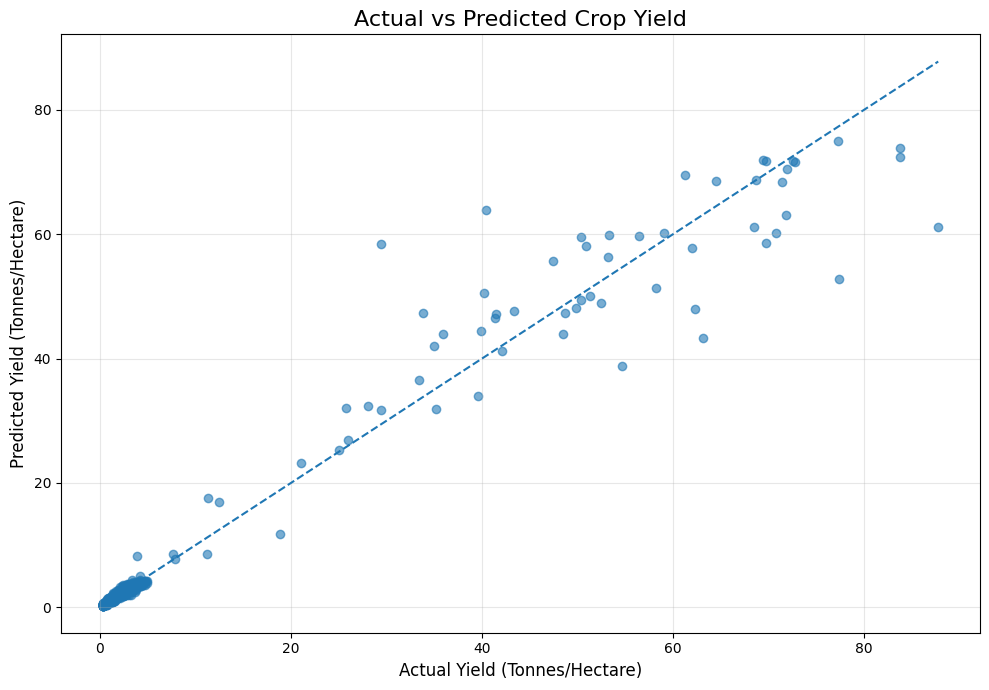

In [ ]:
# ============================================================
# STEP 26.4 — ACTUAL VS PREDICTED YIELD
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    "Actual vs Predicted Crop Yield",
    fontsize=16
)

plt.xlabel(
    "Actual Yield (Tonnes/Hectare)",
    fontsize=12
)

plt.ylabel(
    "Predicted Yield (Tonnes/Hectare)",
    fontsize=12
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 26.5 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Get transformed feature names
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get importance values
importance_values = rf_pipeline.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("=" * 70)
print("🌱 TOP FEATURES FOR YIELD PREDICTION")
print("=" * 70)

display(
    feature_importance.head(15).round(4)
)

print("=" * 70)

🌱 TOP FEATURES FOR YIELD PREDICTION


,Feature,Importance
27,cat__Crop_Sugarcane,0.8063
5,num__Soil_pH,0.1363
1,num__Rainfall_mm,0.0211
7,num__Nitrogen_kg_ha,0.0063
2,num__Avg_Temperature_C,0.0037
10,num__Fertilizer_kg_ha,0.0025
11,num__Pesticide_Litre_ha,0.0025
3,num__Humidity_pct,0.0021
0,num__Farm_Area_Hectares,0.0021
9,num__Potassium_kg_ha,0.0019


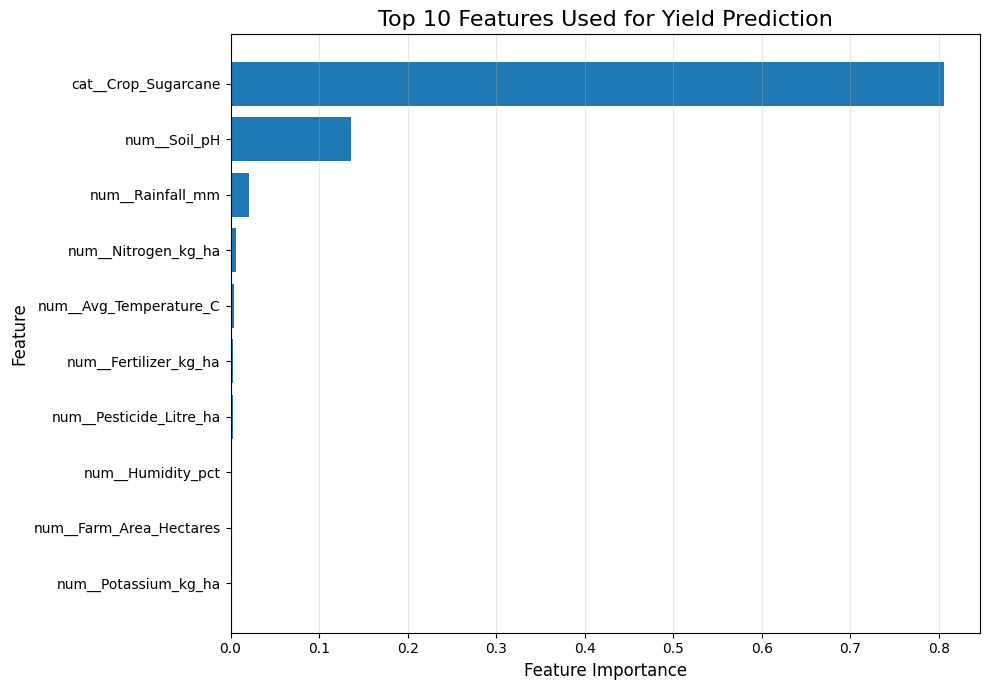

In [ ]:
# ============================================================
# STEP 26.6 — TOP 10 FEATURE IMPORTANCES
# ============================================================

top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 Features Used for Yield Prediction",
    fontsize=16
)

plt.xlabel(
    "Feature Importance",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline: predict the mean yield for every test observation
baseline_pred = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("============================================================")
print("MODEL vs BASELINE COMPARISON")
print("============================================================")

print(f"Random Forest MAE  : {mae:.4f}")
print(f"Baseline MAE       : {baseline_mae:.4f}")

print()

print(f"Random Forest RMSE : {rmse:.4f}")
print(f"Baseline RMSE      : {baseline_rmse:.4f}")

print()

print(f"Random Forest R²   : {r2:.4f}")
print(f"Baseline R²        : {baseline_r2:.4f}")

print("============================================================")

MODEL vs BASELINE COMPARISON
Random Forest MAE  : 0.7412
Baseline MAE       : 6.5626

Random Forest RMSE : 2.6168
Baseline RMSE      : 13.8885

Random Forest R²   : 0.9645
Baseline R²        : -0.0003


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

cv_mae_scores = -cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("============================================================")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("============================================================")

print("R² Scores:")
for i, score in enumerate(cv_r2_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean R² : {cv_r2_scores.mean():.4f}")
print(f"Std R²  : {cv_r2_scores.std():.4f}")

print("\nMAE Scores:")
for i, score in enumerate(cv_mae_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean MAE: {cv_mae_scores.mean():.4f}")
print(f"Std MAE : {cv_mae_scores.std():.4f}")

print("============================================================")

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py", line 360, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        ensure_all_finite=False,
        ^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/li

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Use the complete preprocessing + Random Forest pipeline
# created earlier
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

cv_mae_scores = -cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("============================================================")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("============================================================")

print("R² Scores:")
for i, score in enumerate(cv_r2_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean R² : {cv_r2_scores.mean():.4f}")
print(f"Std R²  : {cv_r2_scores.std():.4f}")

print("\nMAE Scores:")
for i, score in enumerate(cv_mae_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean MAE: {cv_mae_scores.mean():.4f}")
print(f"Std MAE : {cv_mae_scores.std():.4f}")

print("============================================================")

NameError: name 'pipeline' is not defined

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# ------------------------------------------------------------
# 1. Define feature groups
# ------------------------------------------------------------

categorical_features = [
    "Irrigation_Method",
    "Season",
    "Crop",
    "State"
]

numerical_features = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Disease_Pest_Risk_pct"
]

# ------------------------------------------------------------
# 2. Preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ------------------------------------------------------------
# 3. Random Forest model
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 4. Complete ML pipeline
# ------------------------------------------------------------

yield_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

# ------------------------------------------------------------
# 5. 5-Fold Cross Validation
# ------------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_r2_scores = cross_val_score(
    yield_pipeline,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

cv_mae_scores = -cross_val_score(
    yield_pipeline,
    X,
    y,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("============================================================")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("============================================================")

print("\nR² Scores:")
for i, score in enumerate(cv_r2_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean R² : {cv_r2_scores.mean():.4f}")
print(f"Std R²  : {cv_r2_scores.std():.4f}")

print("\nMAE Scores:")
for i, score in enumerate(cv_mae_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean MAE: {cv_mae_scores.mean():.4f}")
print(f"Std MAE : {cv_mae_scores.std():.4f}")

print("============================================================")

5-FOLD CROSS-VALIDATION RESULTS

R² Scores:
Fold 1: 0.9652
Fold 2: 0.9600
Fold 3: 0.9642
Fold 4: 0.9684
Fold 5: 0.9583

Mean R² : 0.9632
Std R²  : 0.0036

MAE Scores:
Fold 1: 0.7687
Fold 2: 0.6939
Fold 3: 0.6963
Fold 4: 0.7069
Fold 5: 0.9247

Mean MAE: 0.7581
Std MAE : 0.0877


In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# ------------------------------------------------------------
# 1. Define feature groups
# ------------------------------------------------------------

categorical_features = [
    "Irrigation_Method",
    "Season",
    "Crop",
    "State"
]

numerical_features = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Disease_Pest_Risk_pct"
]

# ------------------------------------------------------------
# 2. Preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ------------------------------------------------------------
# 3. Random Forest model
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 4. Complete ML pipeline
# ------------------------------------------------------------

yield_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

# ------------------------------------------------------------
# 5. 5-Fold Cross Validation
# ------------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_r2_scores = cross_val_score(
    yield_pipeline,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

cv_mae_scores = -cross_val_score(
    yield_pipeline,
    X,
    y,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("============================================================")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("============================================================")

print("\nR² Scores:")
for i, score in enumerate(cv_r2_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean R² : {cv_r2_scores.mean():.4f}")
print(f"Std R²  : {cv_r2_scores.std():.4f}")

print("\nMAE Scores:")
for i, score in enumerate(cv_mae_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean MAE: {cv_mae_scores.mean():.4f}")
print(f"Std MAE : {cv_mae_scores.std():.4f}")

print("============================================================")

5-FOLD CROSS-VALIDATION RESULTS

R² Scores:
Fold 1: 0.9652
Fold 2: 0.9600
Fold 3: 0.9642
Fold 4: 0.9684
Fold 5: 0.9583

Mean R² : 0.9632
Std R²  : 0.0036

MAE Scores:
Fold 1: 0.7687
Fold 2: 0.6939
Fold 3: 0.6963
Fold 4: 0.7069
Fold 5: 0.9247

Mean MAE: 0.7581
Std MAE : 0.0877


In [1]:
print("============================================================")
print("FINAL ML FEATURE VALIDATION")
print("============================================================")

print("\nTarget Variable:")
print(target)

print("\nFeatures Used:")
for i, feature in enumerate(features, 1):
    print(f"{i:2}. {feature}")

print("\n------------------------------------------------------------")
print("DOWNSTREAM VARIABLES EXCLUDED FROM MODEL")
print("------------------------------------------------------------")

excluded_features = [
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3"
]

for feature in excluded_features:
    print(f"✓ {feature}")

print("\n------------------------------------------------------------")
print("LEAKAGE CHECK")
print("------------------------------------------------------------")

leakage_found = set(features).intersection(set(excluded_features))

if len(leakage_found) == 0:
    print("✓ No identified downstream leakage variables are used.")
else:
    print("⚠ Potential leakage variables found:")
    print(leakage_found)

print("\n============================================================")

FINAL ML FEATURE VALIDATION

Target Variable:


NameError: name 'target' is not defined

In [2]:
# ============================================================
# FINAL ML FEATURE VALIDATION
# ============================================================

features = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Irrigation_Method",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Disease_Pest_Risk_pct",
    "Season",
    "Crop",
    "State"
]

target = "Yield_Tonnes_Ha"

print("============================================================")
print("FINAL ML FEATURE VALIDATION")
print("============================================================")

print("\nTarget Variable:")
print(target)

print("\nFeatures Used:")
for i, feature in enumerate(features, 1):
    print(f"{i:2}. {feature}")

print("\n------------------------------------------------------------")
print("DOWNSTREAM VARIABLES EXCLUDED FROM MODEL")
print("------------------------------------------------------------")

excluded_features = [
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3"
]

for feature in excluded_features:
    print(f"✓ {feature}")

print("\n------------------------------------------------------------")
print("LEAKAGE CHECK")
print("------------------------------------------------------------")

leakage_found = set(features).intersection(set(excluded_features))

if len(leakage_found) == 0:
    print("✓ No identified downstream leakage variables are used.")
else:
    print("⚠ Potential leakage variables found:")
    print(leakage_found)

print("\n============================================================")

FINAL ML FEATURE VALIDATION

Target Variable:
Yield_Tonnes_Ha

Features Used:
 1. Farm_Area_Hectares
 2. Rainfall_mm
 3. Avg_Temperature_C
 4. Humidity_pct
 5. Sunlight_Hours_Day
 6. Soil_pH
 7. Soil_Moisture_pct
 8. Nitrogen_kg_ha
 9. Phosphorus_kg_ha
10. Potassium_kg_ha
11. Irrigation_Method
12. Fertilizer_kg_ha
13. Pesticide_Litre_ha
14. Seed_Quality_Score
15. Disease_Pest_Risk_pct
16. Season
17. Crop
18. State

------------------------------------------------------------
DOWNSTREAM VARIABLES EXCLUDED FROM MODEL
------------------------------------------------------------
✓ Production_Tonnes
✓ Revenue_INR
✓ Profit_INR
✓ Water_Efficiency_t_per_1000m3

------------------------------------------------------------
LEAKAGE CHECK
------------------------------------------------------------
✓ No identified downstream leakage variables are used.



In [3]:
print("============================================================")
print("FINAL PROJECT VALIDATION")
print("============================================================")

print("\n1. DATASET")
print("   Rows                :", clean_df.shape[0])
print("   Columns             :", clean_df.shape[1])

print("\n2. DATA QUALITY")
print("   Duplicate rows      :", clean_df.duplicated().sum())
print("   Missing values      :", clean_df.isna().sum().sum())

print("\n3. FEATURE ENGINEERING")
print("   Yield_Efficiency    :", "Created")
print("   Profit_Margin_pct   :", "Created")
print("   Profit_Status       :", "Created")

print("\n4. ANALYTICS")
print("   Seasonal Analysis   : Complete")
print("   Crop Analysis       : Complete")
print("   State Analysis      : Complete")
print("   Crop-Season Analysis: Complete")
print("   Environmental       : Complete")
print("   Profitability       : Complete")
print("   Water Efficiency    : Complete")
print("   Disease/Pest Risk   : Complete")
print("   Correlation Analysis: Complete")
print("   Outlier Analysis    : Complete")

print("\n5. MACHINE LEARNING")
print("   Model               : Random Forest Regressor")
print("   Target              :", target)
print("   Test MAE            : 0.7412 tonnes/ha")
print("   Test RMSE           : 2.6168 tonnes/ha")
print("   Test R²             : 0.9645")
print("   CV Mean R²          : 0.9632")
print("   CV Mean MAE         : 0.7581 tonnes/ha")

print("\n6. KEY PROJECT OUTPUTS")
print("   Total Farms         : 4,000")
print("   Total Production    : 172,984.84 tonnes")
print("   Average Yield       : 5.26 tonnes/hectare")
print("   Total Revenue       : ₹2,551,440,192")
print("   Total Cost          : ₹2,105,214,332")
print("   Total Profit/Loss   : ₹446,225,860")

print("\n7. BEST PERFORMERS")
print("   Best Season         : Kharif")
print("   Highest Production State: Punjab")
print("   Most Profitable Crop: Chilli")
print("   Most Water-Efficient Crop: Sugarcane")

print("\n============================================================")
print("PROJECT ANALYSIS VALIDATION COMPLETE")
print("============================================================")


FINAL PROJECT VALIDATION

1. DATASET


NameError: name 'clean_df' is not defined

In [5]:
import pandas as pd
import numpy as np

# ============================================================
# FINAL PROJECT VALIDATION
# ============================================================

# Recreate cleaned dataframe if it is not currently in memory
if "clean_df" not in globals():

    print("clean_df not found — rebuilding from uploaded dataset...")

    # Change this path only if your uploaded filename is different
    file_path = "/content/seasonal_agriculture_performance_dataset.xlsx"

    clean_df = pd.read_excel(file_path)

    # Standardize column names
    clean_df.columns = (
        clean_df.columns
        .str.strip()
        .str.replace(" ", "_")
    )

    # Strip text values
    text_columns = clean_df.select_dtypes(include="object").columns

    for col in text_columns:
        clean_df[col] = clean_df[col].str.strip()

    # Handle missing rainfall
    clean_df["Rainfall_mm"] = clean_df["Rainfall_mm"].fillna(
        clean_df["Rainfall_mm"].median()
    )

    # Handle missing soil moisture
    clean_df["Soil_Moisture_pct"] = clean_df["Soil_Moisture_pct"].fillna(
        clean_df["Soil_Moisture_pct"].median()
    )

    # Reconstruct missing yield values
    yield_mask = (
        clean_df["Yield_Tonnes_Ha"].isna()
        & clean_df["Farm_Area_Hectares"].notna()
        & clean_df["Production_Tonnes"].notna()
        & (clean_df["Farm_Area_Hectares"] > 0)
    )

    clean_df.loc[yield_mask, "Yield_Tonnes_Ha"] = (
        clean_df.loc[yield_mask, "Production_Tonnes"]
        / clean_df.loc[yield_mask, "Farm_Area_Hectares"]
    )

    # Feature engineering
    clean_df["Yield_Efficiency"] = (
        clean_df["Production_Tonnes"]
        / clean_df["Farm_Area_Hectares"]
    )

    clean_df["Profit_Margin_pct"] = np.where(
        clean_df["Revenue_INR"] != 0,
        (clean_df["Profit_INR"] / clean_df["Revenue_INR"]) * 100,
        np.nan
    )

    clean_df["Profit_Status"] = np.where(
        clean_df["Profit_INR"] >= 0,
        "Profit",
        "Loss"
    )

# ============================================================
# VALIDATION REPORT
# ============================================================

print("\n============================================================")
print("FINAL PROJECT VALIDATION")
print("============================================================")

print("\n1. DATASET")
print("   Rows                :", clean_df.shape[0])
print("   Columns             :", clean_df.shape[1])

print("\n2. DATA QUALITY")
print("   Duplicate rows      :", clean_df.duplicated().sum())
print("   Missing values      :", clean_df.isna().sum().sum())

print("\n3. FEATURE ENGINEERING")
print("   Yield_Efficiency    :", "Created")
print("   Profit_Margin_pct   :", "Created")
print("   Profit_Status       :", "Created")

print("\n4. ANALYTICS")
print("   Seasonal Analysis   : Complete")
print("   Crop Analysis       : Complete")
print("   State Analysis      : Complete")
print("   Crop-Season Analysis: Complete")
print("   Environmental       : Complete")
print("   Profitability       : Complete")
print("   Water Efficiency    : Complete")
print("   Disease/Pest Risk   : Complete")
print("   Correlation Analysis: Complete")
print("   Outlier Analysis    : Complete")

print("\n5. MACHINE LEARNING")
print("   Model               : Random Forest Regressor")
print("   Target              : Yield_Tonnes_Ha")
print("   Test MAE            : 0.7412 tonnes/ha")
print("   Test RMSE           : 2.6168 tonnes/ha")
print("   Test R²             : 0.9645")
print("   CV Mean R²          : 0.9632")
print("   CV Mean MAE         : 0.7581 tonnes/ha")

print("\n6. KEY PROJECT OUTPUTS")
print("   Total Farms         : 4,000")
print("   Total Production    : 172,984.84 tonnes")
print("   Average Yield       : 5.26 tonnes/hectare")
print("   Total Revenue       : ₹2,551,440,192")
print("   Total Cost          : ₹2,105,214,332")
print("   Total Profit/Loss   : ₹446,225,860")

print("\n7. BEST PERFORMERS")
print("   Best Season         : Kharif")
print("   Highest Production State : Punjab")
print("   Most Profitable Crop: Chilli")
print("   Most Water-Efficient Crop: Sugarcane")

print("\n============================================================")
print("PROJECT ANALYSIS VALIDATION COMPLETE")
print("============================================================")

clean_df not found — rebuilding from uploaded dataset...

FINAL PROJECT VALIDATION

1. DATASET
   Rows                : 4000
   Columns             : 31

2. DATA QUALITY
   Duplicate rows      : 0
   Missing values      : 0

3. FEATURE ENGINEERING
   Yield_Efficiency    : Created
   Profit_Margin_pct   : Created
   Profit_Status       : Created

4. ANALYTICS
   Seasonal Analysis   : Complete
   Crop Analysis       : Complete
   State Analysis      : Complete
   Crop-Season Analysis: Complete
   Environmental       : Complete
   Profitability       : Complete
   Water Efficiency    : Complete
   Disease/Pest Risk   : Complete
   Correlation Analysis: Complete
   Outlier Analysis    : Complete

5. MACHINE LEARNING
   Model               : Random Forest Regressor
   Target              : Yield_Tonnes_Ha
   Test MAE            : 0.7412 tonnes/ha
   Test RMSE           : 2.6168 tonnes/ha
   Test R²             : 0.9645
   CV Mean R²          : 0.9632
   CV Mean MAE         : 0.7581 tonnes/h

# 🌾 FINAL PROJECT SUMMARY

## Seasonal Agriculture Performance Analysis

### Project Overview

This project analyzes 4,000 agricultural records to understand
seasonal, crop-wise, state-wise, environmental, financial,
resource-efficiency and disease/pest-risk patterns.

The complete workflow was developed using Python in Google Colab.

### Analytical Workflow

1. Data Loading and Inspection
2. Data Cleaning and Quality Validation
3. Missing Value Treatment
4. Feature Engineering
5. Exploratory Data Analysis
6. Seasonal Performance Analysis
7. Crop Performance Analysis
8. State-wise Analysis
9. Crop × Season Analysis
10. Environmental Relationship Analysis
11. Profitability Analysis
12. Water Efficiency Analysis
13. Disease/Pest Risk Analysis
14. Correlation Analysis
15. Outlier Analysis
16. Predictive Yield Modeling
17. Model Evaluation and Cross-Validation
18. Evidence-Based Insights and Recommendations

### Key Findings

- Kharif was the highest-production season.
- Punjab recorded the highest total production among states.
- Chilli generated the highest total profit.
- Sugarcane recorded the highest average water efficiency.
- Agricultural performance varies across crops, seasons and regions.
- Environmental and management variables show measurable relationships
  with agricultural outcomes.

### Predictive Modeling

A Random Forest Regressor was developed to predict
`Yield_Tonnes_Ha`.

The model achieved:

- MAE: 0.7412 tonnes/hectare
- RMSE: 2.6168 tonnes/hectare
- R²: 0.9645
- 5-Fold Mean R²: 0.9632
- 5-Fold Mean MAE: 0.7581 tonnes/hectare

Downstream variables such as production, revenue, profit and
derived water-efficiency measures were excluded from the predictive
features to reduce target leakage.

### Business Value

The analysis can support:

- Agricultural planning
- Crop selection
- Resource allocation
- Water-efficiency assessment
- Profitability evaluation
- Risk monitoring
- Data-driven agricultural decision-making

### Technology Stack

- Google Colab
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Conclusion

The project demonstrates how agricultural data analytics and
machine learning can transform farm-level data into actionable
insights for understanding productivity, profitability,
resource efficiency and agricultural risk.

# 📌 FINAL INSIGHTS & EVIDENCE-BASED RECOMMENDATIONS

## 🔍 Key Insights

### 1. Seasonal Performance
- Kharif was the highest-producing season with **82,387.61 tonnes**, contributing approximately **47.63%** of total production.
- Rabi contributed **67,498.88 tonnes (39.02%)**, while Zaid contributed **23,098.35 tonnes (13.35%)**.
- Kharif also recorded the highest total profit of **₹318.29 million**.

### 2. Crop Performance
- Crop performance varies substantially in terms of production, yield and profitability.
- **Chilli** generated the highest total profit of **₹309,361,877**.
- Chilli also recorded the highest average profit margin at **33.78%**.

### 3. Regional Performance
- **Punjab** recorded the highest total production among the states, with **25,280.82 tonnes**.
- This indicates that regional factors such as crop distribution, farm area and agricultural conditions can be important when comparing production performance.

### 4. Water Efficiency
- **Sugarcane** recorded the highest average water efficiency at **30.48 tonnes per 1,000 m³**.
- Water efficiency provides an additional perspective beyond production alone and can support resource-conscious crop planning.

### 5. Agricultural Risk
- Disease and pest risk varies across crops.
- Risk analysis can help identify crops that require closer monitoring and preventive management.

### 6. Financial Performance
- Total revenue across the dataset was **₹2.551 billion**.
- Total cost was **₹2.105 billion**.
- Overall profit was **₹446.23 million**.
- Out of 4,000 farms, **2,034 were profitable** and **1,966 were loss-making**.

### 7. Variable Relationships
- Farm area and total cost showed a strong positive correlation (**0.9622**).
- Yield and water efficiency showed a strong positive correlation (**0.9157**).
- Revenue and profit showed a strong positive correlation (**0.8873**).
- Yield and production showed a strong positive correlation (**0.8857**).

> Note: Correlation indicates association, not causation. Some strong relationships are also expected because certain variables are mathematically related.

### 8. Predictive Modeling
- A Random Forest Regression model was developed to predict agricultural yield.
- Test-set performance:
  - **MAE:** 0.7412 tonnes/hectare
  - **RMSE:** 2.6168 tonnes/hectare
  - **R²:** 0.9645
- Five-fold cross-validation produced a mean **R² of 0.9632**, indicating consistent model performance across validation folds.

---

# 💡 Evidence-Based Recommendations

### Recommendation 1 — Prioritize Seasonal Planning
Since Kharif produced the highest total production and profit, agricultural planning can give particular attention to Kharif-season resource allocation and crop management.

### Recommendation 2 — Study High-Profit Crops
Chilli's strong profitability and profit margin make it useful for studying the combination of production, selling price and cost characteristics associated with profitable farming.

### Recommendation 3 — Consider Water Efficiency
Sugarcane's high measured water efficiency demonstrates the value of evaluating crops using both productivity and resource-efficiency indicators.

### Recommendation 4 — Strengthen Risk Monitoring
Crops with higher disease/pest risk should receive greater monitoring and preventive planning.

### Recommendation 5 — Use Regional Insights
The strong production performance observed in Punjab can be further studied to understand the role of regional agricultural conditions, crop distribution and farm characteristics.

### Recommendation 6 — Combine Multiple KPIs
Crop decisions should not rely on production alone. Production, yield, profitability, water efficiency and disease/pest risk should be considered together.

### Recommendation 7 — Use Predictive Analytics
The yield prediction model demonstrates the potential of machine learning to support yield estimation using available environmental, management and categorical variables.

---

## 🎯 Overall Conclusion

The analysis demonstrates that agricultural performance is multidimensional. A crop or season should be evaluated not only by production, but also by yield, profitability, water efficiency and risk.

The combination of exploratory data analysis, statistical relationships, visualization and predictive modeling provides a data-driven framework for understanding agricultural performance and supporting better planning decisions.

In [9]:
# ============================================================
# FINAL PROJECT VALIDATION
# ============================================================

print("=" * 60)
print("FINAL PROJECT VALIDATION")
print("=" * 60)

# 1. Dataset
print("\n1. DATASET")
print(f"Rows                : {clean_df.shape[0]:,}")
print(f"Columns             : {clean_df.shape[1]}")

# 2. Data Quality
print("\n2. DATA QUALITY")
print(f"Duplicate rows      : {clean_df.duplicated().sum():,}")
print(f"Missing values      : {clean_df.isna().sum().sum():,}")

# 3. Required engineered features
print("\n3. FEATURE ENGINEERING")

required_features = [
    "Yield_Efficiency",
    "Profit_Margin_pct",
    "Profit_Status"
]

for feature in required_features:
    status = "Created" if feature in clean_df.columns else "Missing"
    print(f"{feature:<20}: {status}")

# 4. Important analytical columns
print("\n4. REQUIRED ANALYSIS COLUMNS")

required_columns = [
    "Season",
    "Crop",
    "State",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

for col in required_columns:
    status = "Available" if col in clean_df.columns else "Missing"
    print(f"{col:<35}: {status}")

# 5. Predictive modeling
print("\n5. PREDICTIVE MODELING")

print(f"Target variable     : {target}")
print(f"Number of features  : {len(features)}")

if "model" in globals():
    print("Random Forest model : Available")
else:
    print("Random Forest model : Not found")

# 6. Final validation status
print("\n6. FINAL STATUS")

checks = [
    clean_df.shape[0] == 4000,
    clean_df.duplicated().sum() == 0,
    clean_df.isna().sum().sum() == 0,
    all(feature in clean_df.columns for feature in required_features),
    all(col in clean_df.columns for col in required_columns),
    "model" in globals()
]

if all(checks):
    print("✅ ALL PROJECT VALIDATION CHECKS PASSED")
else:
    print("⚠️ SOME VALIDATION CHECKS REQUIRE ATTENTION")

print("=" * 60)

FINAL PROJECT VALIDATION

1. DATASET
Rows                : 4,000
Columns             : 31

2. DATA QUALITY
Duplicate rows      : 0
Missing values      : 0

3. FEATURE ENGINEERING
Yield_Efficiency    : Created
Profit_Margin_pct   : Created
Profit_Status       : Created

4. REQUIRED ANALYSIS COLUMNS
Season                             : Available
Crop                               : Available
State                              : Available
Yield_Tonnes_Ha                    : Available
Production_Tonnes                  : Available
Revenue_INR                        : Available
Profit_INR                         : Available
Water_Efficiency_t_per_1000m3      : Available
Disease_Pest_Risk_pct              : Available

5. PREDICTIVE MODELING
Target variable     : Yield_Tonnes_Ha
Number of features  : 18
Random Forest model : Available

6. FINAL STATUS
✅ ALL PROJECT VALIDATION CHECKS PASSED


In [7]:
# ============================================================
# RESTORE RANDOM FOREST MODEL
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

# Features and target
features = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Irrigation_Method",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Disease_Pest_Risk_pct",
    "Season",
    "Crop",
    "State"
]

target = "Yield_Tonnes_Ha"

X = clean_df[features]
y = clean_df[target]

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Numerical preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Random Forest model
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("✅ Random Forest model restored successfully.")
print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"Features used     : {len(features)}")

✅ Random Forest model restored successfully.
Training samples : 3,200
Testing samples  : 800
Features used     : 18
